# Bayesian modelling of chocolate quality rating
#### Authors: Julia Wiktorowicz, Patrycja Wybranowska

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from cmdstanpy import CmdStanModel
import arviz as az
import matplotlib
import matplotlib.colors as mcolors

RELATIVE = False


## Data preprocessing
The raw data from Flavors of Cacao database contains information about producer and its origin country, country and details of bean origin, basic ingredients, most memorable characteristics, final rating and date of the review.



In [39]:
columns = [
    'REF', 'Company', 'Company Location', 'Review Date', 
    'Country of Bean Origin', 'Specific Bean Origin', 
    'Cocoa Percent', 'Ingredients', 'Most Memorable Characteristics', 'Rating'
]

df_pre = pd.read_csv('data/data.txt', sep='\t', names=columns, skiprows=1) if RELATIVE else pd.read_csv('/workspace/project2/Chocolate-DA/data/data.txt', sep='\t', names=columns, skiprows=1)
df_pre.head()

,REF,Company,Company Location,Review Date,Country of Bean Origin,Specific Bean Origin,Cocoa Percent,Ingredients,Most Memorable Characteristics,Rating
0,3016,Cacao Store,Japan,2026,Thailand,Chumphon,70%,"3- B,S,C","light apricot, pear, nutty, clean",3.25
1,3016,Cacao Store,Japan,2026,Taiwan,Fu-Wan,70%,"3- B,S,C","cocoa,roasty,pungent, chemical",2.75
2,3016,Cacao Store,Japan,2026,Madagascar,Ambanja,75%,"3- B,S,C","high acid, atypical honey",3.00
3,3016,URA,Peru,2026,Peru,"Piura, Chulucanas, Finca Tito Jimenez",70%,"3- B,S,C","grapes, roast (smoke like)",3.75
4,3020,URA,Peru,2026,Peru,"VRAEM 99, Pichari, Cusco, Finca Daria",70%,"3- B,S,C",plum,3.50


In [40]:
df = pd.read_csv('data/chocolate_data_preprocessed.csv') if RELATIVE else pd.read_csv('/workspace/project2/Chocolate-DA/data/chocolate_data_preprocessed.csv')

observed_ratings = sorted(df['Rating'].unique())     # only values that actually occur
rating_map = {val: i + 1 for i, val in enumerate(observed_ratings)}
inv_rating_map = {v: k for k, v in rating_map.items()}   # build this here, right next to rating_map

df['rating_id'] = df['Rating'].map(rating_map)
C = len(observed_ratings)
J = df['Bean Origin ID'].max()
K = df['Company Location ID'].max()


print(f"C = {C}")
print(df['rating_id'].value_counts().sort_index())
print(f"NaNs in rating_id: {df['rating_id'].isna().sum()}")  # should be 0
df.head()

# for each bean origin, find the most common producer location
origin_to_loc = (
    df.groupby('Bean Origin ID')['Company Location ID']
    .agg(lambda x: x.mode()[0])
    .to_dict()
)
# list of length J: for origin j, which producer location is it primarily from
origin_location = [int(origin_to_loc[j]) for j in range(1, J + 1)]

C = 8
rating_id
1      3
2     54
3    113
4    248
5    223
6    276
7    118
8     41
Name: count, dtype: int64
NaNs in rating_id: 0


### Prior predictive check

In [41]:
prior_model1 = CmdStanModel(stan_file="prior_model1.stan") if RELATIVE else CmdStanModel(stan_file="/workspace/project2/Chocolate-DA/prior_model1.stan")

J = df['Bean Origin ID'].max()
K = df['Company Location ID'].max()

prior_data1 = {
    "N": len(df),
    "J": J,
    "K": K,
    "C": C,
    "origin":          df['Bean Origin ID'].tolist(),
    "producer":        df['Company Location ID'].tolist(),
    "origin_location": origin_location,    # ← new, must be computed before this cell
}


prior_fit1 = prior_model1.sample(
    data=prior_data1,
    fixed_param=True,
    iter_sampling=2000,
    chains=1,
    seed=42,
    show_progress=False,
)



# pull everything including the new parameters
rating_pred_prior1   = prior_fit1.stan_variable("rating_pred")
a_prior_draws1       = prior_fit1.stan_variable("alpha")
b_prior_draws1       = prior_fit1.stan_variable("gamma")
mu_global_prior1     = prior_fit1.stan_variable("mu_global")     # ← was missing
sigma_origin_prior1  = prior_fit1.stan_variable("sigma_origin")
sigma_prod_prior1    = prior_fit1.stan_variable("sigma_producer")
sigma_lam_prior1     = prior_fit1.stan_variable("sigma_lambda")  # ← was missing
alpha_prior1         = prior_fit1.stan_variable("alpha")
gamma_prior1         = prior_fit1.stan_variable("gamma")         # ← was missing
c_prior_draws        = prior_fit1.stan_variable("c")

20:01:53 - cmdstanpy - INFO - CmdStan start processing
20:01:53 - cmdstanpy - INFO - Chain [1] start processing
20:01:56 - cmdstanpy - INFO - Chain [1] done processing


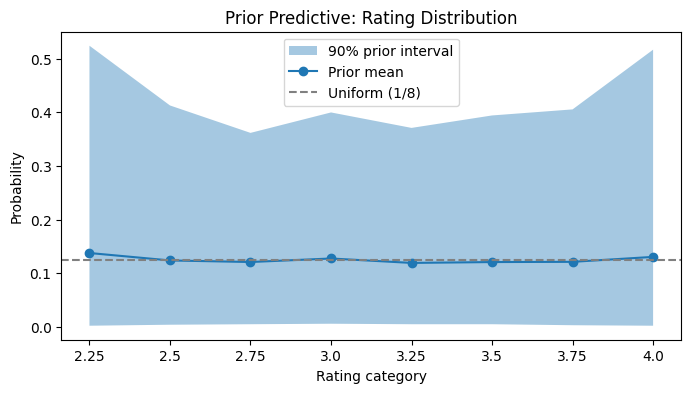

In [42]:
fig, ax = plt.subplots(figsize=(8, 4))
# rating_pred shape: (n_draws, N) — average over observations
pred_counts = np.apply_along_axis(
    lambda x: np.bincount(x.astype(int) - 1, minlength=C), 1, rating_pred_prior1
)
pred_probs = pred_counts / pred_counts.sum(axis=1, keepdims=True)

ax.fill_between(
    range(1, C+1),
    np.percentile(pred_probs, 5, axis=0),
    np.percentile(pred_probs, 95, axis=0),
    alpha=0.4, label="90% prior interval"
)
ax.plot(range(1, C+1), pred_probs.mean(axis=0), marker='o', label="Prior mean")
ax.axhline(1/C, ls='--', color='gray', label=f"Uniform (1/{C})")
ax.set_xlabel("Rating category"); ax.set_ylabel("Probability")
ax.set_title("Prior Predictive: Rating Distribution")
xticks = [inv_rating_map[i+1] for i in range(8)]
ax.set_xticks(range(1, C+1))
ax.set_xticklabels(xticks)
ax.legend()

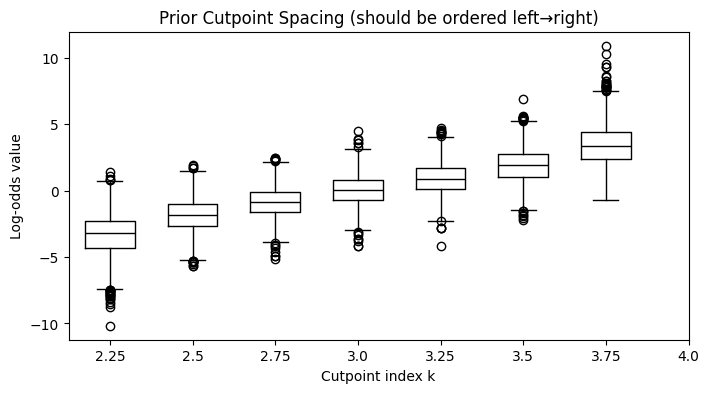

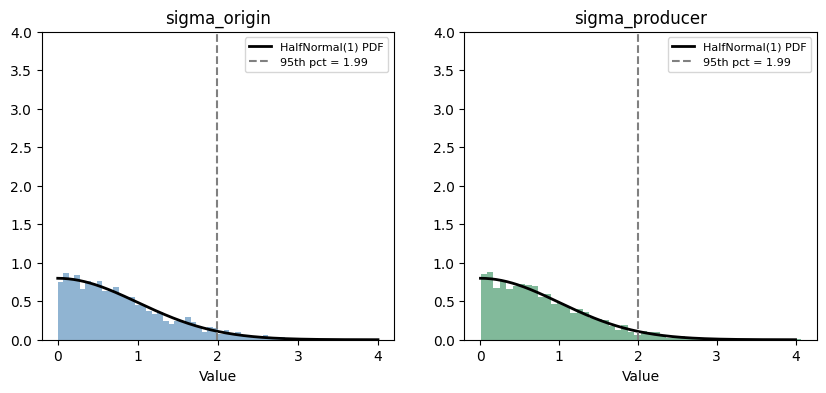

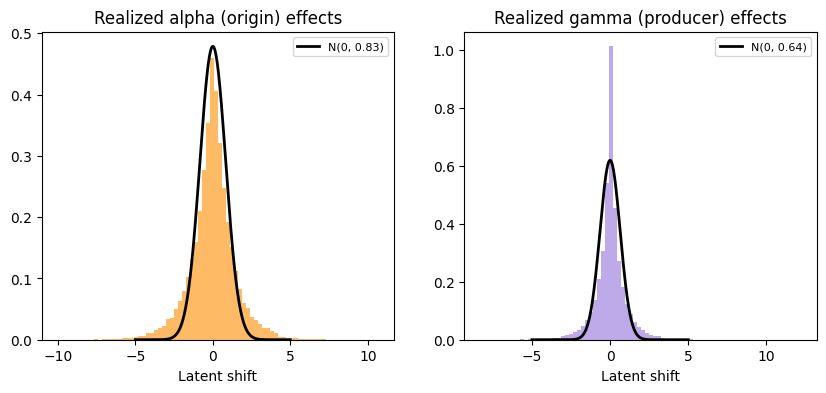

In [43]:
fig, ax = plt.subplots(figsize=(8, 4))
for k in range(C - 1):
    ax.boxplot(c_prior_draws[:, k], positions=[k+1], widths=0.6,
               medianprops=dict(color='black'))
ax.set_xlabel("Cutpoint index k")
ax.set_ylabel("Log-odds value")
ax.set_title("Prior Cutpoint Spacing (should be ordered left→right)")
ax.set_xticks(range(1, C+1))
ax.set_xticklabels(xticks)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x = np.linspace(0, 4, 300)
ref = stats.halfnorm.pdf(x, scale=1.0)

for ax, samples, name, color in zip(
    axes,
    [sigma_origin_prior1, sigma_prod_prior1],
    ["sigma_origin", "sigma_producer"],
    ["steelblue", "seagreen"]
):
    ax.hist(samples, bins=50, density=True, alpha=0.6, color=color)
    ax.plot(x, ref, 'k-', lw=2, label="HalfNormal(1) PDF")
    ax.axvline(np.percentile(samples, 95), ls='--', color='gray',
               label=f"95th pct = {np.percentile(samples,95):.2f}")
    ax.set_title(f"{name}")
    ax.set_xlabel("Value"); ax.legend(fontsize=8)
    ax.set_ylim([0, 4])
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, draws, name, color in zip(
    axes, [a_prior_draws1, b_prior_draws1],
    ["alpha (origin)", "gamma (producer)"], ["darkorange", "mediumpurple"]
):
    ax.hist(draws.flatten(), bins=80, density=True, alpha=0.6, color=color)
    # overlay a N(0, median_sigma) reference
    med_sigma = np.median(draws.std(axis=1))
    x = np.linspace(-5, 5, 300)
    
    ax.plot(x, stats.norm.pdf(x, 0, med_sigma), 'k-', lw=2,
            label=f"N(0, {med_sigma:.2f})")
    ax.set_title(f"Realized {name} effects")
    ax.set_xlabel("Latent shift"); ax.legend(fontsize=8)

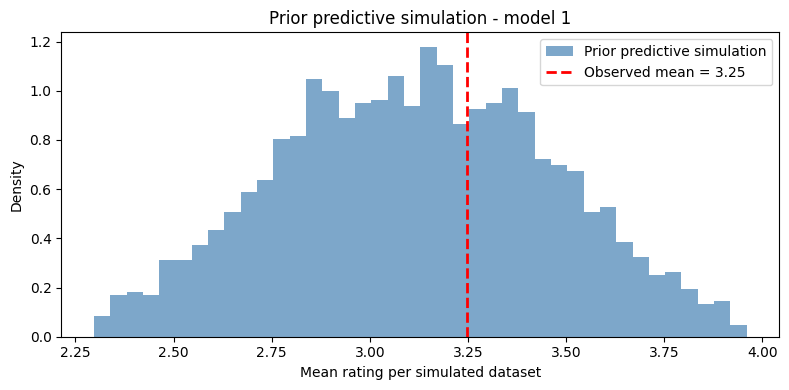

In [44]:
id_to_rating = np.vectorize(inv_rating_map.get)
rating_pred_values = id_to_rating(rating_pred_prior1)

prior_draw_means1 = rating_pred_values.mean(axis=1)
observed_mean = df["Rating"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prior_draw_means1, bins=40, density=True, alpha=0.7,
        color="steelblue", label="Prior predictive simulation")
ax.axvline(observed_mean, color="red", lw=2, ls="--",
           label=f"Observed mean = {observed_mean:.2f}")
ax.set_xlabel("Mean rating per simulated dataset")
ax.set_ylabel("Density")
ax.set_title("Prior predictive simulation - model 1")
ax.legend()
plt.tight_layout()
plt.show()

## posterior model 1

20:02:01 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

20:03:08 - cmdstanpy - INFO - CmdStan done processing.
20:03:08 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -504.891, but should be greater than the previous element, -504.891 (in 'model_1.stan', line 64, column 2 to column 36)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -505.672, but should be greater than the previous element, -505.672 (in 'model_1.stan', line 64, column 2 to column 36)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is -125.61, but should be greater than the previous element, -125.61 (in 'model_1.stan', line 64, column 2 to column 36)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is -29.9186, but should be greater than the previous element, -29.9186 (in 'model_1.stan', line 64, column 2 to column 36)
	Exception: ordered_logistic: Loca


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.


Parameters with R-hat > 1.01: 0

Parameters with ESS < 400: 0


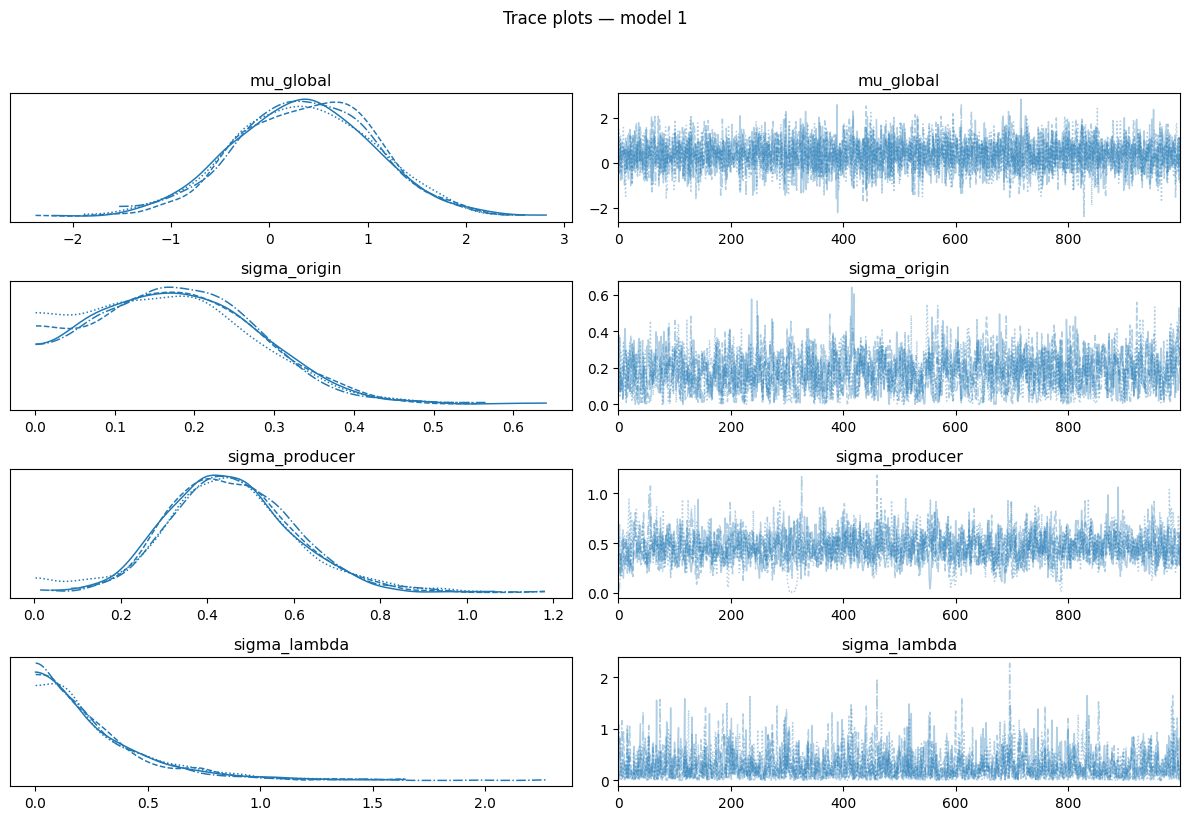

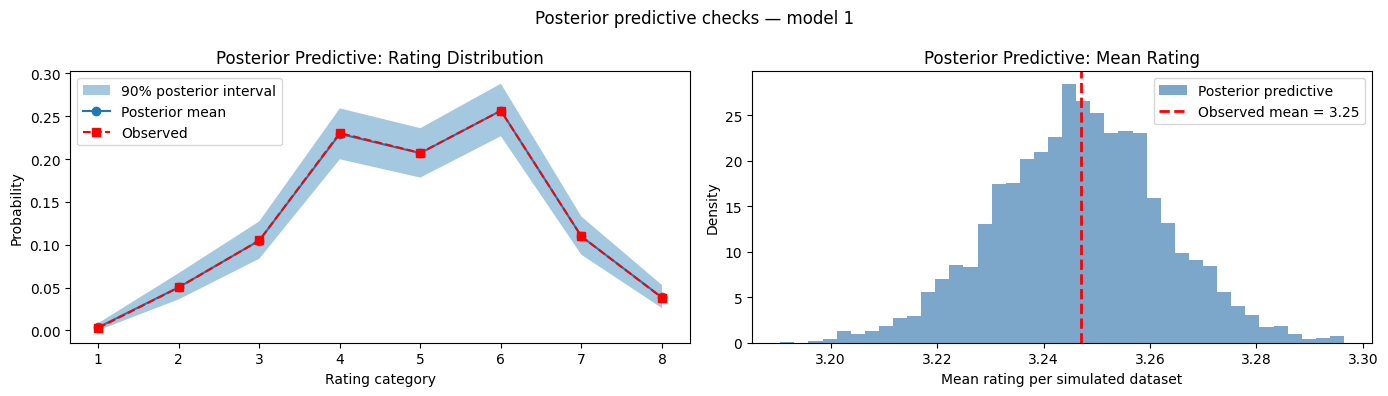

In [45]:
# ── Fit ───────────────────────────────────────────────────────────────────────
model_1_fit = CmdStanModel(stan_file="model_1.stan") if RELATIVE else CmdStanModel(stan_file="/workspace/project2/Chocolate-DA/model_1.stan")

data_sim1 = {
    "N": len(df),
    "J": J,
    "K": K,
    "C": C,
    "origin":          df['Bean Origin ID'].tolist(),
    "producer":        df['Company Location ID'].tolist(),
    "rating":          df['rating_id'].tolist(),
    "origin_location": origin_location,
}

fit1 = model_1_fit.sample(
    data=data_sim1,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42,
    show_progress=True,   # keep on so you can see if chains get stuck
)

# ── Pull posterior samples ─────────────────────────────────────────────────────
# pull posterior samples
# pull posterior samples
rating_pred_post1  = fit1.stan_variable("rating_pred")
alpha_samples1     = fit1.stan_variable("alpha")
gamma_samples1     = fit1.stan_variable("gamma")
lambda_samples1    = fit1.stan_variable("lambda")
sigma_origin1      = fit1.stan_variable("sigma_origin")
sigma_producer1    = fit1.stan_variable("sigma_producer")
sigma_lambda1      = fit1.stan_variable("sigma_lambda")
mu_global_samples1 = fit1.stan_variable("mu_global")
c_samples1         = fit1.stan_variable("c")

# ← this line was missing — map category ids (1–8) back to real rating values
id_to_rating     = np.vectorize(inv_rating_map.get)
rating_pred_vals = id_to_rating(rating_pred_post1)   # (draws, N), values like 2.75, 3.0 etc.

# ← this line was missing — map category ids (1–8) back to real rating values
id_to_rating     = np.vectorize(inv_rating_map.get)
rating_pred_vals = id_to_rating(rating_pred_post1)   # (draws, N), values like 2.75, 3.0 etc.

# ── Convergence diagnostics ───────────────────────────────────────────────────
print(fit1.diagnose())   # divergences, treedepth, E-BFMI — read this carefully

idata1 = az.from_cmdstanpy(fit1)   # convert once, reuse below

summary1 = az.summary(idata1)
bad_rhat = summary1[summary1['r_hat'] > 1.01]
bad_ess  = summary1[summary1['ess_bulk'] < 400]

print(f"\nParameters with R-hat > 1.01: {len(bad_rhat)}")
if len(bad_rhat) > 0:
    print(bad_rhat[['mean','sd','r_hat','ess_bulk']].head(20))

print(f"\nParameters with ESS < 400: {len(bad_ess)}")
if len(bad_ess) > 0:
    print(bad_ess[['mean','sd','r_hat','ess_bulk']].head(20))

# ── Trace plots for global params (visual convergence check) ──────────────────
az.plot_trace(idata1, var_names=["mu_global", "sigma_origin",
                                  "sigma_producer", "sigma_lambda"])
plt.suptitle("Trace plots — model 1", y=1.02)
plt.tight_layout()
plt.show()

# ── Posterior predictive check ────────────────────────────────────────────────
# map predicted category ids back to real rating values
id_to_rating    = np.vectorize(inv_rating_map.get)
pred_values     = id_to_rating(rating_pred_post1)          # (draws, N)

pred_counts = np.apply_along_axis(
    lambda x: np.bincount(x.astype(int) - 1, minlength=C),
    1, rating_pred_post1
)
pred_probs = pred_counts / pred_counts.sum(axis=1, keepdims=True)

# observed distribution
obs_counts = np.bincount(df['rating_id'].values.astype(int) - 1, minlength=C)
obs_probs  = obs_counts / obs_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# left: category-level posterior predictive vs observed
ax = axes[0]
ax.fill_between(
    range(1, C + 1),
    np.percentile(pred_probs, 5,  axis=0),
    np.percentile(pred_probs, 95, axis=0),
    alpha=0.4, label="90% posterior interval"
)
ax.plot(range(1, C + 1), pred_probs.mean(axis=0),
        marker='o', label="Posterior mean")
ax.plot(range(1, C + 1), obs_probs,
        marker='s', color='red', ls='--', label="Observed")
ax.set_xlabel("Rating category")
ax.set_ylabel("Probability")
ax.set_title("Posterior Predictive: Rating Distribution")
ax.legend()

# right: simulated vs observed mean rating
ax = axes[1]
post_means   = pred_values.mean(axis=1)
observed_mean = df["Rating"].mean()
ax.hist(post_means, bins=40, density=True, alpha=0.7,
        color="steelblue", label="Posterior predictive")
ax.axvline(observed_mean, color="red", lw=2, ls="--",
           label=f"Observed mean = {observed_mean:.2f}")
ax.set_xlabel("Mean rating per simulated dataset")
ax.set_ylabel("Density")
ax.set_title("Posterior Predictive: Mean Rating")
ax.legend()

plt.suptitle("Posterior predictive checks — model 1")
plt.tight_layout()
plt.show()

Non-fatal warnings occured at the start of the warmup phase but they did not affect the validity of the final posterior draws. The MCMC sampling process was completed successfully with no problems detected. The R_hat values for all parameters are smaller than 1.01 indicating optimal chain convergence. 

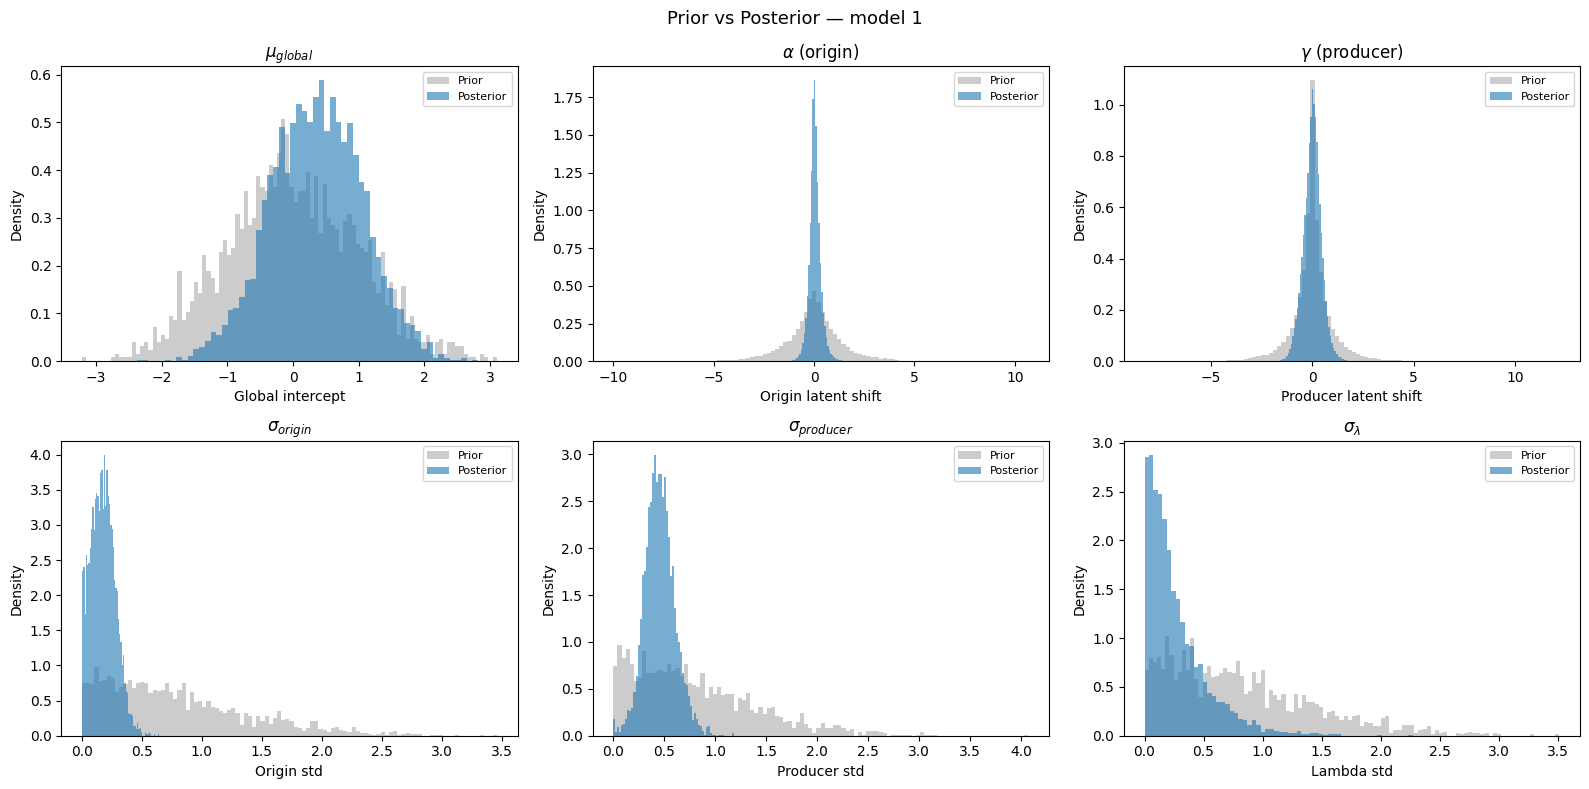

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

panels = [
    (mu_global_samples1,       mu_global_prior1,        r"$\mu_{global}$",        "Global intercept"),
    (alpha_samples1.flatten(), alpha_prior1.flatten(),   r"$\alpha$ (origin)",     "Origin latent shift"),
    (gamma_samples1.flatten(), gamma_prior1.flatten(),   r"$\gamma$ (producer)",   "Producer latent shift"),
    (sigma_origin1,            sigma_origin_prior1,      r"$\sigma_{origin}$",     "Origin std"),
    (sigma_producer1,          sigma_prod_prior1,        r"$\sigma_{producer}$",   "Producer std"),
    (sigma_lambda1,            sigma_lam_prior1,         r"$\sigma_{\lambda}$",    "Lambda std"),
]

for ax, (post, prior, title, xlabel) in zip(axes, panels):
    ax.hist(prior, bins=100, density=True, alpha=0.4, color="gray", label="Prior")
    ax.hist(post,  bins=60,  density=True, alpha=0.6, label="Posterior")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Prior vs Posterior — model 1", fontsize=13)
plt.tight_layout()
plt.show()

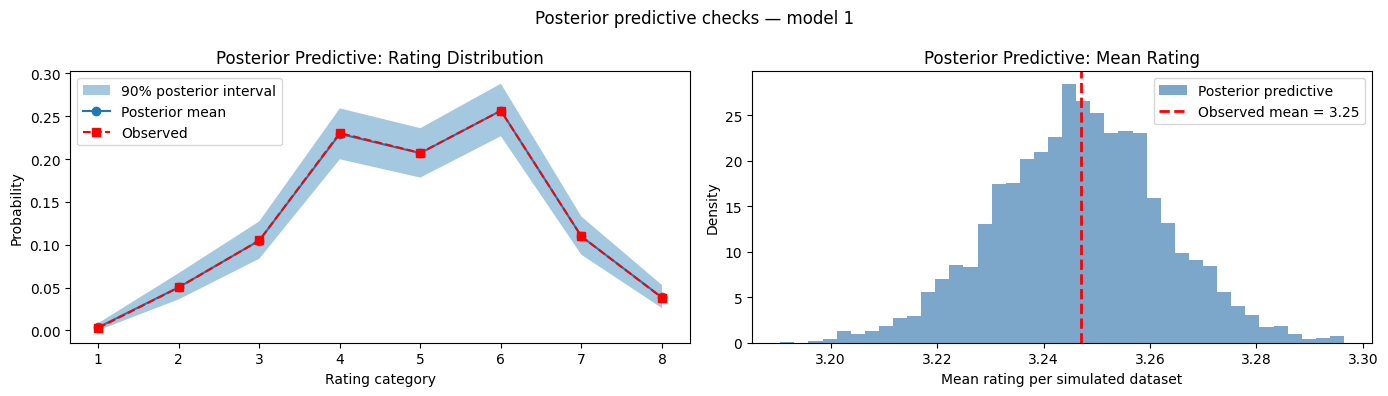

In [47]:
pred_counts = np.apply_along_axis(
    lambda x: np.bincount(x.astype(int) - 1, minlength=C), 1, rating_pred_post1
)
pred_probs = pred_counts / pred_counts.sum(axis=1, keepdims=True)
obs_counts = np.bincount(df['rating_id'].values.astype(int) - 1, minlength=C)
obs_probs  = obs_counts / obs_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.fill_between(
    range(1, C + 1),
    np.percentile(pred_probs, 5,  axis=0),
    np.percentile(pred_probs, 95, axis=0),
    alpha=0.4, label="90% posterior interval"
)
ax.plot(range(1, C + 1), pred_probs.mean(axis=0), marker='o', label="Posterior mean")
ax.plot(range(1, C + 1), obs_probs, marker='s',
        color='red', ls='--', label="Observed")
ax.set_xlabel("Rating category")
ax.set_ylabel("Probability")
ax.set_title("Posterior Predictive: Rating Distribution")
ax.legend()

ax = axes[1]
ax.hist(rating_pred_vals.mean(axis=1), bins=40, density=True, alpha=0.7,
        color="steelblue", label="Posterior predictive")
ax.axvline(df["Rating"].mean(), color="red", lw=2, ls="--",
           label=f"Observed mean = {df['Rating'].mean():.2f}")
ax.set_xlabel("Mean rating per simulated dataset")
ax.set_ylabel("Density")
ax.set_title("Posterior Predictive: Mean Rating")
ax.legend()

plt.suptitle("Posterior predictive checks — model 1")
plt.tight_layout()
plt.show()

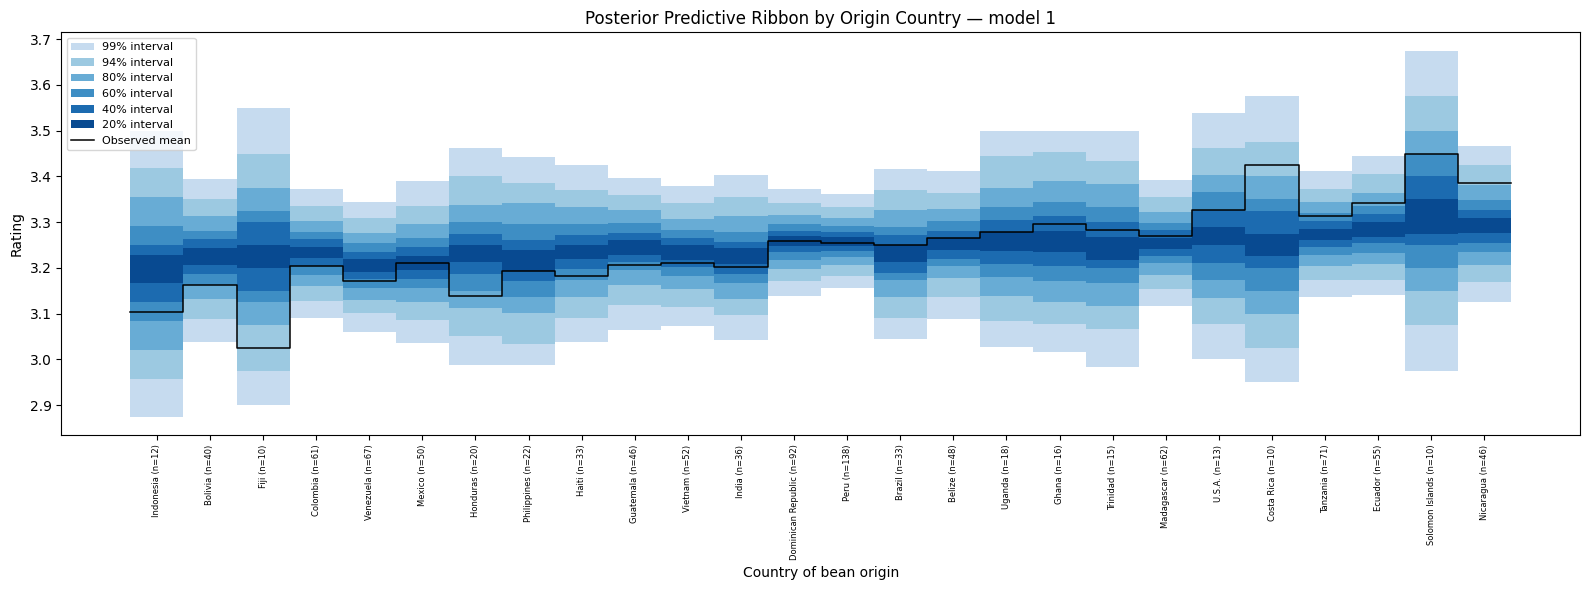

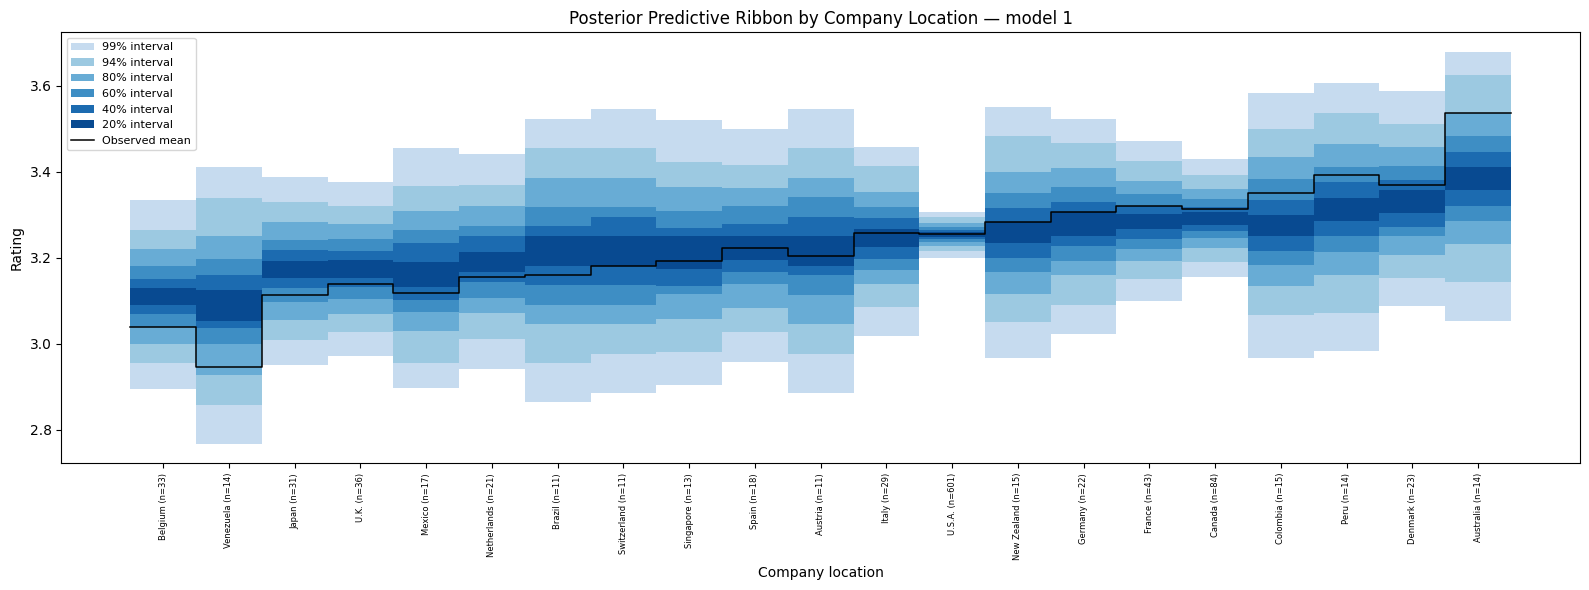

In [48]:
# ── 3. Ribbon plot by bean origin country ─────────────────────────────────────
# latent score for each origin = global mean + origin effect
mu_origin_total1 = mu_global_samples1[:, None] + alpha_samples1  # (draws, J)

current_df = df.copy().reset_index(drop=True)
countries   = sorted(current_df["Country of Bean Origin"].unique())
country_idx = {c: i + 1 for i, c in enumerate(countries)}
current_df["country_id"] = current_df["Country of Bean Origin"].map(country_idx)
counts_origin = current_df["Country of Bean Origin"].value_counts().to_dict()

results11 = pd.DataFrame({
    "country":     countries,
    "mu_mean":     mu_origin_total1.mean(axis=0),
    "mu_lower_94": np.percentile(mu_origin_total1, 3,  axis=0),
    "mu_upper_94": np.percentile(mu_origin_total1, 97, axis=0),
    "n_bars":      [counts_origin.get(c, 0) for c in countries],
}).sort_values("mu_mean", ascending=True).reset_index(drop=True)

observed_per_country1 = current_df.groupby("country_id")["Rating"].mean()
obs_sorted_origin = results11["country"].map(
    lambda c: observed_per_country1[country_idx[c]]
).values

J_sorted1 = len(results11)
x2        = np.arange(1, J_sorted1 + 1)
num_draws = rating_pred_vals.shape[0]

post_pred_means_origin = np.zeros((num_draws, J_sorted1))
for i, country_name in enumerate(results11["country"]):
    idx = current_df[current_df["Country of Bean Origin"] == country_name].index.values
    post_pred_means_origin[:, i] = rating_pred_vals[:, idx].mean(axis=1)

def step_edges(values, x):
    edges   = np.concatenate([x - 0.5, x[-1:] + 0.5])
    stepped = np.concatenate([[values[0]], values])
    return edges, stepped

levels = [99, 94, 80, 60, 40, 20]
cmap   = matplotlib.colormaps["Blues"]
colors = [mcolors.to_hex(cmap(f)) for f in np.linspace(0.25, 0.9, len(levels))]

fig, ax = plt.subplots(figsize=(16, 6))
for lev, color in zip(levels, colors):
    lo = np.percentile(post_pred_means_origin, (100 - lev) / 2,       axis=0)
    hi = np.percentile(post_pred_means_origin, 100 - (100 - lev) / 2, axis=0)
    e, ls = step_edges(lo, x2); _, hs = step_edges(hi, x2)
    ax.fill_between(e, ls, hs, step="pre", color=color,
                    linewidth=0, label=f"{lev}% interval")

e, os = step_edges(obs_sorted_origin, x2)
ax.step(e, os, where="pre", color="black", linewidth=1.1, label="Observed mean")
ax.set_xticks(x2)
ax.set_xticklabels(
    [f"{r['country']} (n={r['n_bars']})" for _, r in results11.iterrows()],
    rotation=90, fontsize=6
)
ax.set_xlabel("Country of bean origin"); ax.set_ylabel("Rating")
ax.set_title("Posterior Predictive Ribbon by Origin Country — model 1")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# ── 4. Ribbon plot by company (producer) location ─────────────────────────────
mu_company_total1 = mu_global_samples1[:, None] + gamma_samples1   # (draws, K)

company_locations = sorted(current_df["Company Location"].unique())
company_idx       = {c: i + 1 for i, c in enumerate(company_locations)}
current_df["company_id"] = current_df["Company Location"].map(company_idx)
counts_company = current_df["Company Location"].value_counts().to_dict()

results12 = pd.DataFrame({
    "company":     company_locations,
    "mu_mean":     mu_company_total1.mean(axis=0),
    "mu_lower_94": np.percentile(mu_company_total1, 3,  axis=0),
    "mu_upper_94": np.percentile(mu_company_total1, 97, axis=0),
    "n_bars":      [counts_company.get(c, 0) for c in company_locations],
}).sort_values("mu_mean", ascending=True).reset_index(drop=True)

observed_per_company1 = current_df.groupby("company_id")["Rating"].mean()
obs_sorted_company = results12["company"].map(
    lambda c: observed_per_company1[company_idx[c]]
).values

K_sorted = len(results12)
x3       = np.arange(1, K_sorted + 1)

post_pred_means_company = np.zeros((num_draws, K_sorted))
for i, comp_name in enumerate(results12["company"]):
    idx = current_df[current_df["Company Location"] == comp_name].index.values
    post_pred_means_company[:, i] = rating_pred_vals[:, idx].mean(axis=1)

fig, ax = plt.subplots(figsize=(16, 6))
for lev, color in zip(levels, colors):
    lo = np.percentile(post_pred_means_company, (100 - lev) / 2,       axis=0)
    hi = np.percentile(post_pred_means_company, 100 - (100 - lev) / 2, axis=0)
    e, ls = step_edges(lo, x3); _, hs = step_edges(hi, x3)
    ax.fill_between(e, ls, hs, step="pre", color=color,
                    linewidth=0, label=f"{lev}% interval")

e, cs = step_edges(obs_sorted_company, x3)
ax.step(e, cs, where="pre", color="black", linewidth=1.1, label="Observed mean")
ax.set_xticks(x3)
ax.set_xticklabels(
    [f"{r['company']} (n={r['n_bars']})" for _, r in results12.iterrows()],
    rotation=90, fontsize=6
)
ax.set_xlabel("Company location"); ax.set_ylabel("Rating")
ax.set_title("Posterior Predictive Ribbon by Company Location — model 1")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

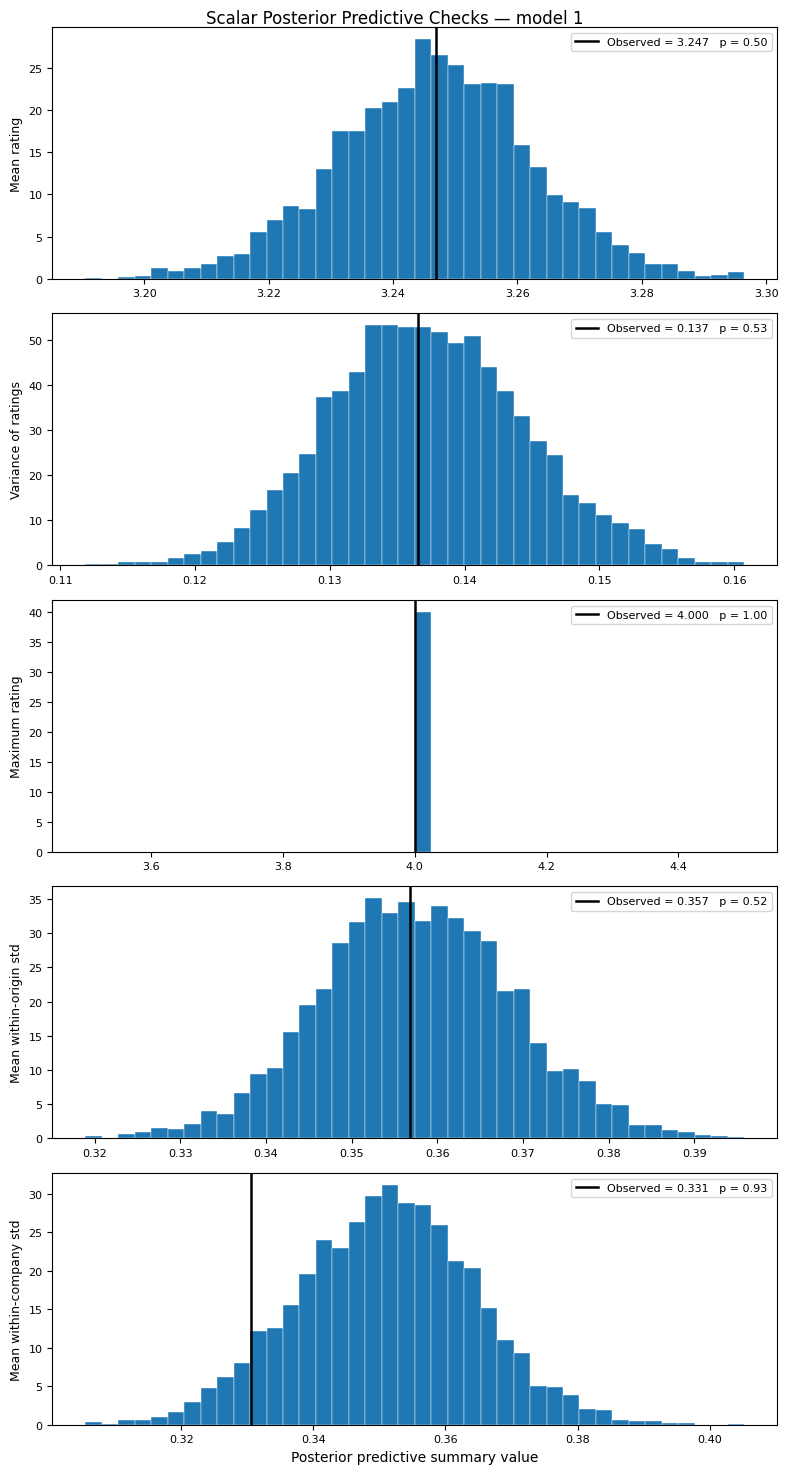

In [49]:
obs     = df["Rating"].values
y_rep   = rating_pred_vals          # already on real scale

rep_mean = y_rep.mean(axis=1)
rep_var  = y_rep.var(axis=1)
rep_max  = y_rep.max(axis=1)

# within-country std
country_sds_rep = np.zeros((num_draws, J_sorted1))
country_sds_obs = np.zeros(J_sorted1)
for i, country_name in enumerate(results11["country"]):
    idx = current_df[current_df["Country of Bean Origin"] == country_name].index.values
    if len(idx) > 1:
        country_sds_rep[:, i] = y_rep[:, idx].std(axis=1)
        country_sds_obs[i]    = obs[idx].std()
mean_country_sd_rep = country_sds_rep.mean(axis=1)
mean_country_sd_obs = country_sds_obs.mean()

# within-company std
company_sds_rep = np.zeros((num_draws, K_sorted))
company_sds_obs = np.zeros(K_sorted)
for i, comp_name in enumerate(results12["company"]):
    idx = current_df[current_df["Company Location"] == comp_name].index.values
    if len(idx) > 1:
        company_sds_rep[:, i] = y_rep[:, idx].std(axis=1)
        company_sds_obs[i]    = obs[idx].std()
mean_company_sd_rep = company_sds_rep.mean(axis=1)
mean_company_sd_obs = company_sds_obs.mean()

checks = [
    (rep_mean,           obs.mean(),          "Mean rating"),
    (rep_var,            obs.var(),           "Variance of ratings"),
    (rep_max,            obs.max(),           "Maximum rating"),
    (mean_country_sd_rep, mean_country_sd_obs, "Mean within-origin std"),
    (mean_company_sd_rep, mean_company_sd_obs, "Mean within-company std"),
]

fig, axes = plt.subplots(5, 1, figsize=(8, 15))
for ax, (rep_stat, obs_stat, ylabel) in zip(axes, checks):
    ax.hist(rep_stat, bins=40, density=True, edgecolor="white", linewidth=0.3)
    p_val = np.mean(rep_stat >= obs_stat)
    ax.axvline(obs_stat, color="k", linewidth=1.8,
               label=f"Observed = {obs_stat:.3f}   p = {p_val:.2f}")
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel("Posterior predictive summary value", fontsize=10)
plt.suptitle("Scalar Posterior Predictive Checks — model 1", fontsize=12)
plt.tight_layout()
plt.show()

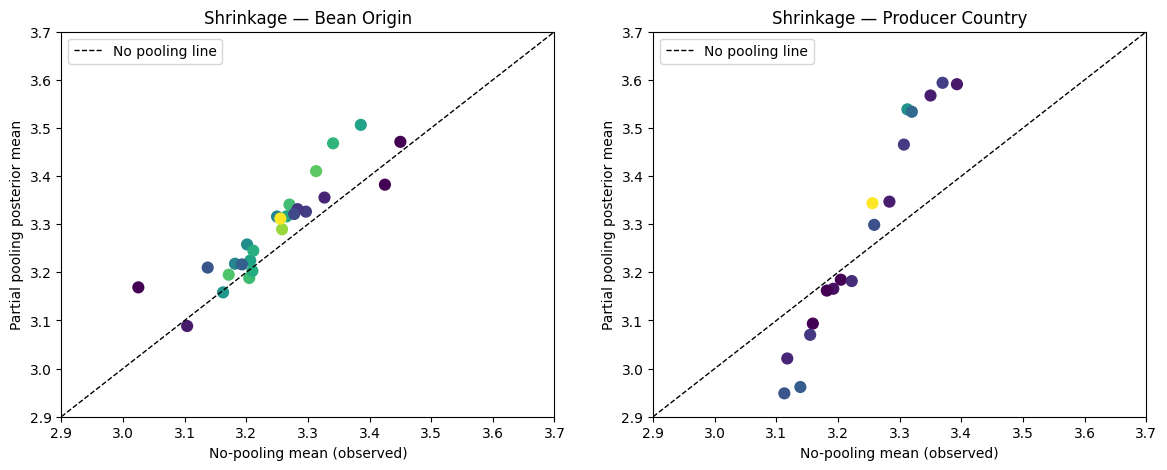

In [50]:
# For each origin j: no-pooling mean vs posterior mean alpha
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convert posterior alpha to predicted rating space
# For each group j, compute E[rating | alpha_j] using posterior mean phi
global_mean = mu_global_samples1.mean()

for ax, samples, id_col, title in zip(
    axes,
    [alpha_samples1, gamma_samples1],
    ['Bean Origin ID', 'Company Location ID'],
    ['Bean Origin', 'Producer Country']
):
    group_obs_mean = df.groupby(id_col)['Rating'].mean()
    group_ns       = df.groupby(id_col)['Rating'].count()
    
    # posterior mean effect + global intercept, converted to rating scale
    post_alpha_mean = samples.mean(axis=0)  # latent
    # map global_mean + alpha to expected rating via cutpoints
    # simplest approximation: use linear mapping through observed mean
    grand_mean = df['Rating'].mean()
    post_rating_mean = grand_mean + post_alpha_mean  # rough but same scale
    
    ax.scatter(group_obs_mean.values, post_rating_mean,
               c=np.log(group_ns.values), cmap='viridis', s=60)
    lims = [2.9, 3.7]
    ax.plot(lims, lims, 'k--', lw=1, label='No pooling line')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.axhline(df['Rating'].mean() - df['Rating'].mean(), color='gray')  
    ax.set_xlabel('No-pooling mean (observed)')
    ax.set_ylabel('Partial pooling posterior mean')
    ax.set_title(f'Shrinkage — {title}')
    ax.legend()

[Text(1, 0, 'c1\n2.25|2.50'),
 Text(2, 0, 'c2\n2.50|2.75'),
 Text(3, 0, 'c3\n2.75|3.00'),
 Text(4, 0, 'c4\n3.00|3.25'),
 Text(5, 0, 'c5\n3.25|3.50'),
 Text(6, 0, 'c6\n3.50|3.75'),
 Text(7, 0, 'c7\n3.75|4.00')]

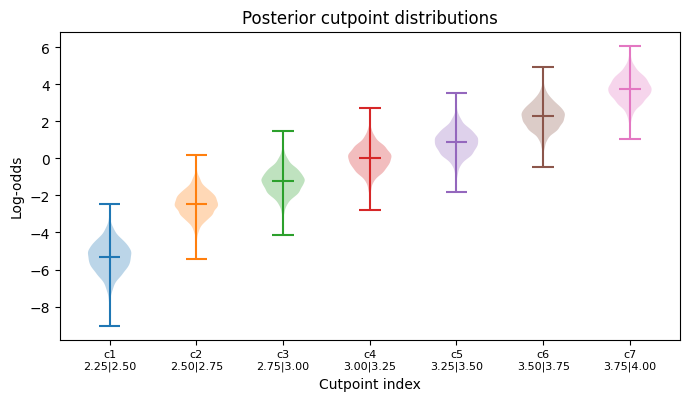

In [51]:
rating_labels = ['2.25|2.50', '2.50|2.75', '2.75|3.00', 
                 '3.00|3.25', '3.25|3.50', '3.50|3.75', '3.75|4.00']

fig, ax = plt.subplots(figsize=(8, 4))
for k in range(C - 1):
    ax.violinplot(c_samples1[:, k], positions=[k+1], showmedians=True)
ax.set_xlabel('Cutpoint index')
ax.set_ylabel('Log-odds')
ax.set_title('Posterior cutpoint distributions')
ax.set_xticks(range(1, 8))
ax.set_xticklabels([f'c{k}\n{rating_labels[k-1]}' for k in range(1, 8)], fontsize=8)

## Model 2


In [52]:
# Add to preprocessing section, after df is loaded

# Cocoa% → logit transform
cocoa_num = df['Cocoa Percent'].str.replace('%', '').astype(float) / 100
df['cocoa_logit'] = np.log(cocoa_num / (1 - cocoa_num))

# Normalize cocoa_logit (helps sampler, keeps prior scale interpretable)
df['cocoa_logit_norm'] = (df['cocoa_logit'] - df['cocoa_logit'].mean()) / df['cocoa_logit'].std()

# N_ingredients already normalized in your data — use that
# Drop Has_vanilla (redundant with N_ingredients as discussed)

print(df[['Cocoa Percent', 'cocoa_logit', 'cocoa_logit_norm', 
          'Number of ingredients norm']].describe())

       cocoa_logit  cocoa_logit_norm  Number of ingredients norm
count  1076.000000      1.076000e+03                1.076000e+03
mean      0.927297     -2.377281e-16                5.282846e-17
std       0.191533      1.000000e+00                1.000000e+00
min       0.405465     -2.724507e+00               -1.148561e+00
25%       0.847298     -4.176787e-01               -1.148561e+00
50%       0.847298     -4.176787e-01                3.458184e-01
75%       0.994623      3.515102e-01                3.458184e-01
max       2.197225      6.630349e+00                4.828958e+00


20:03:56 - cmdstanpy - INFO - CmdStan start processing
20:03:56 - cmdstanpy - INFO - Chain [1] start processing
20:03:58 - cmdstanpy - INFO - Chain [1] done processing
20:03:58 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

20:05:26 - cmdstanpy - INFO - CmdStan done processing.
20:05:26 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -495.342, but should be greater than the previous element, -495.342 (in 'model_2pw.stan', line 67, column 2 to column 36)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -496.406, but should be greater than the previous element, -496.406 (in 'model_2pw.stan', line 67, column 2 to column 36)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is -123.116, but should be greater than the previous element, -123.116 (in 'model_2pw.stan', line 67, column 2 to column 36)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is -29.6222, but should be greater than the previous element, -29.6222 (in 'model_2pw.stan', line 67, column 2 to column 36)
	Exception: ordered_logi


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.

R-hat > 1.01: 0
ESS < 400:    0


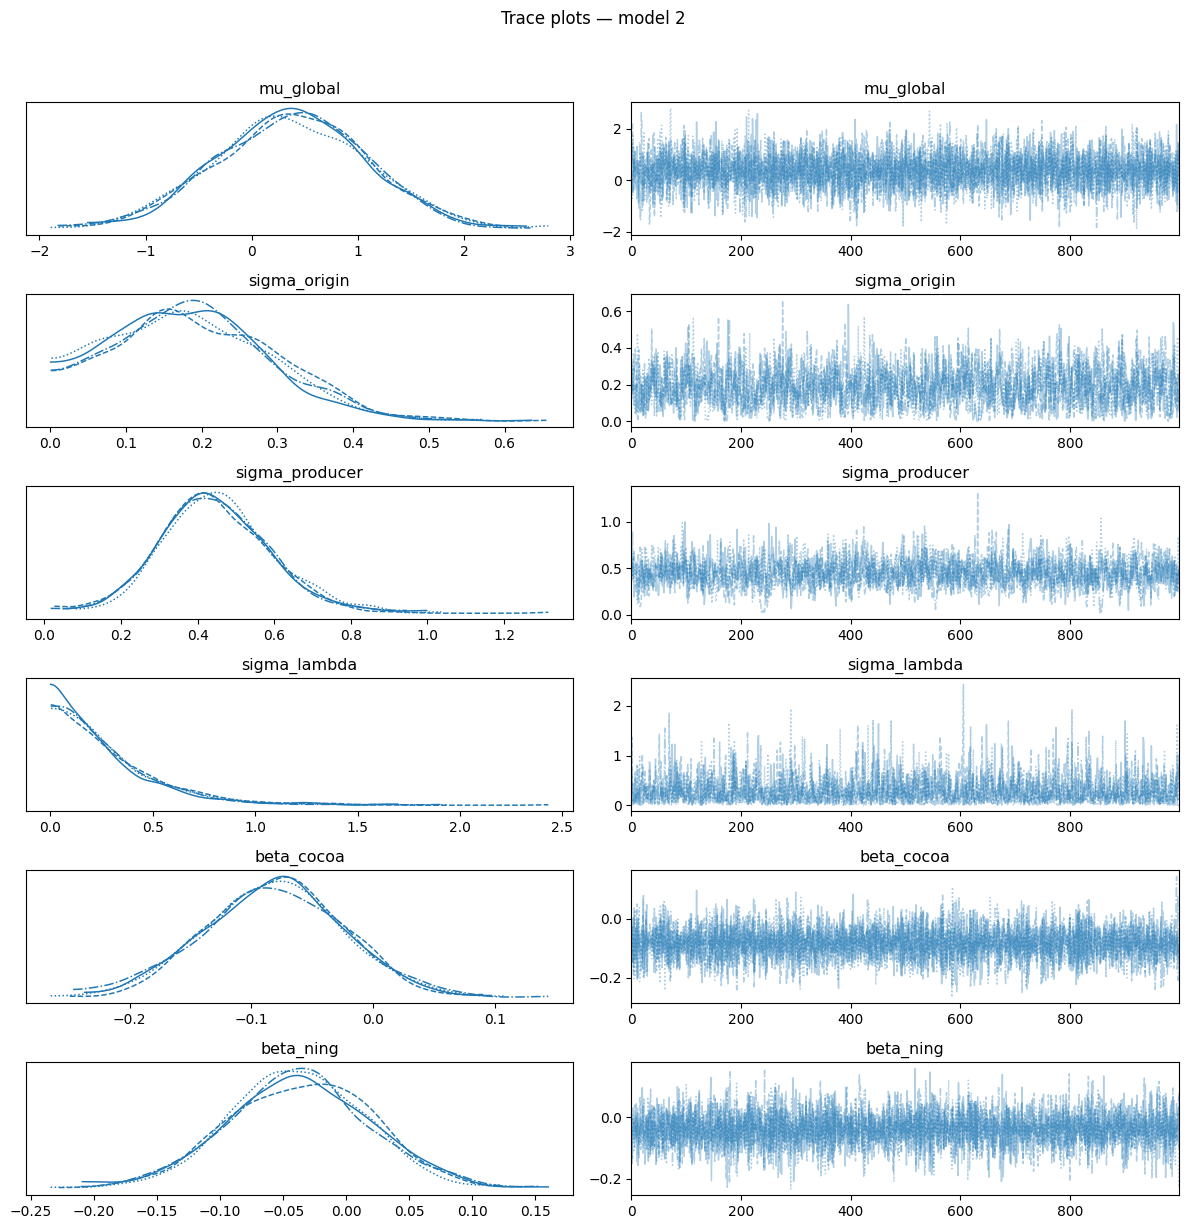

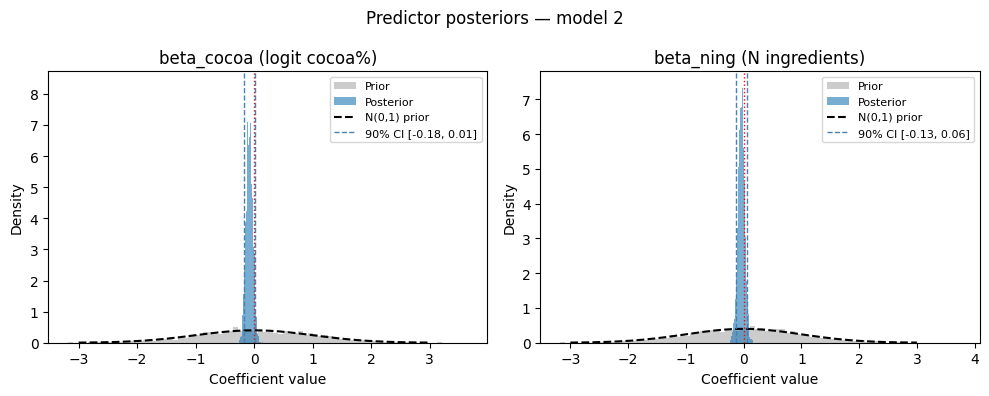

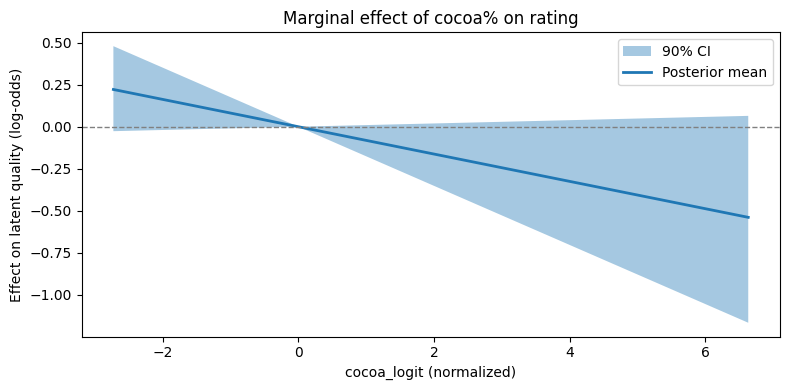

In [53]:
prior_model2 = CmdStanModel(
    stan_file="prior_model2pw.stan" if RELATIVE 
    else "/workspace/project2/Chocolate-DA/prior_model2pw.stan"
)

prior_data2 = {
    "N": len(df),
    "J": J, "K": K, "C": C,
    "origin":          df['Bean Origin ID'].tolist(),
    "producer":        df['Company Location ID'].tolist(),
    "origin_location": origin_location,
    "cocoa_logit":     df['cocoa_logit_norm'].tolist(),
    "n_ingredients":   df['Number of ingredients norm'].tolist(),
}

prior_fit2 = prior_model2.sample(
    data=prior_data2, fixed_param=True,
    iter_sampling=2000, chains=1, seed=42, show_progress=False,
)

rating_pred_prior2 = prior_fit2.stan_variable("rating_pred")
beta_cocoa_prior   = prior_fit2.stan_variable("beta_cocoa")
beta_ning_prior    = prior_fit2.stan_variable("beta_ning")

# ── Fit model 2 ───────────────────────────────────────────────────────────────
model2_fit = CmdStanModel(
    stan_file="model_2pw.stan" if RELATIVE
    else "/workspace/project2/Chocolate-DA/model_2pw.stan"
)

data_sim2 = {**prior_data2, "rating": df['rating_id'].tolist()}

fit2 = model2_fit.sample(
    data=data_sim2, chains=4,
    iter_warmup=1000, iter_sampling=1000,
    seed=42, show_progress=True,
)

# ── Pull posterior samples ────────────────────────────────────────────────────
rating_pred_post2  = fit2.stan_variable("rating_pred")
alpha_samples2     = fit2.stan_variable("alpha")
gamma_samples2     = fit2.stan_variable("gamma")
lambda_samples2    = fit2.stan_variable("lambda")
sigma_origin2      = fit2.stan_variable("sigma_origin")
sigma_producer2    = fit2.stan_variable("sigma_producer")
sigma_lambda2      = fit2.stan_variable("sigma_lambda")
mu_global_samples2 = fit2.stan_variable("mu_global")
c_samples2         = fit2.stan_variable("c")
beta_cocoa_post    = fit2.stan_variable("beta_cocoa")
beta_ning_post     = fit2.stan_variable("beta_ning")

rating_pred_vals2  = id_to_rating(rating_pred_post2)

idata2 = az.from_cmdstanpy(fit2)

# ── Diagnostics ───────────────────────────────────────────────────────────────
print(fit2.diagnose())
summary2  = az.summary(idata2)
bad_rhat2 = summary2[summary2['r_hat'] > 1.01]
bad_ess2  = summary2[summary2['ess_bulk'] < 400]
print(f"R-hat > 1.01: {len(bad_rhat2)}")
print(f"ESS < 400:    {len(bad_ess2)}")

az.plot_trace(idata2, var_names=["mu_global", "sigma_origin", "sigma_producer",
                                  "sigma_lambda", "beta_cocoa", "beta_ning"])
plt.suptitle("Trace plots — model 2", y=1.02)
plt.tight_layout(); plt.show()

# ── Beta posteriors (key new plot for model 2) ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x = np.linspace(-3, 3, 300)

for ax, post, prior, name in zip(
    axes,
    [beta_cocoa_post, beta_ning_post],
    [beta_cocoa_prior, beta_ning_prior],
    ["beta_cocoa (logit cocoa%)", "beta_ning (N ingredients)"]
):
    ax.hist(prior, bins=80, density=True, alpha=0.4, color='gray', label='Prior')
    ax.hist(post,  bins=60, density=True, alpha=0.6, label='Posterior')
    ax.plot(x, stats.norm.pdf(x, 0, 1), 'k--', lw=1.5, label='N(0,1) prior')
    ax.axvline(0, color='red', ls=':', lw=1)
    ax.axvline(np.percentile(post, 5),  color='steelblue', ls='--', lw=1)
    ax.axvline(np.percentile(post, 95), color='steelblue', ls='--', lw=1,
               label=f"90% CI [{np.percentile(post,5):.2f}, {np.percentile(post,95):.2f}]")
    ax.set_title(name); ax.set_xlabel("Coefficient value")
    ax.set_ylabel("Density"); ax.legend(fontsize=8)

plt.suptitle("Predictor posteriors — model 2")
plt.tight_layout(); plt.show()

# ── Cocoa% marginal effect plot ───────────────────────────────────────────────
cocoa_grid   = np.linspace(df['cocoa_logit_norm'].min(),
                            df['cocoa_logit_norm'].max(), 100)
cocoa_effect = np.outer(beta_cocoa_post, cocoa_grid)  # (draws, 100)

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(
    cocoa_grid,
    np.percentile(cocoa_effect, 5,  axis=0),
    np.percentile(cocoa_effect, 95, axis=0),
    alpha=0.4, label="90% CI"
)
ax.plot(cocoa_grid, cocoa_effect.mean(axis=0), lw=2, label="Posterior mean")
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_xlabel("cocoa_logit (normalized)")
ax.set_ylabel("Effect on latent quality (log-odds)")
ax.set_title("Marginal effect of cocoa% on rating")
ax.legend(); plt.tight_layout(); plt.show()


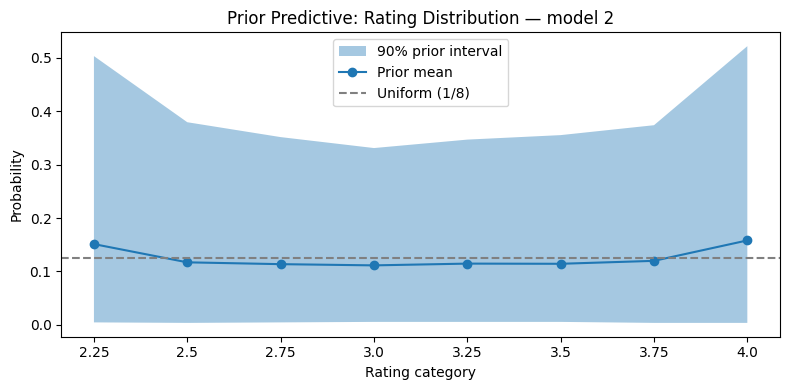

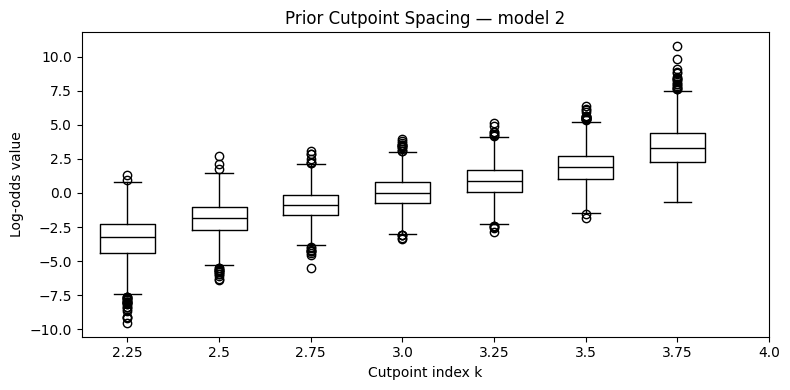

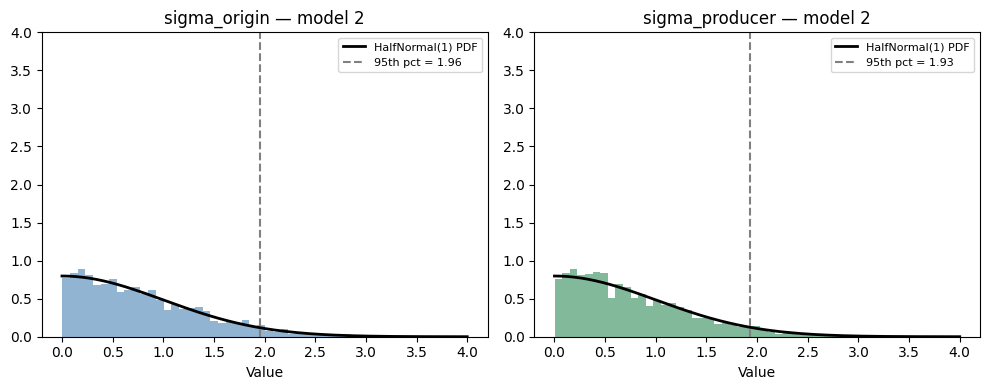

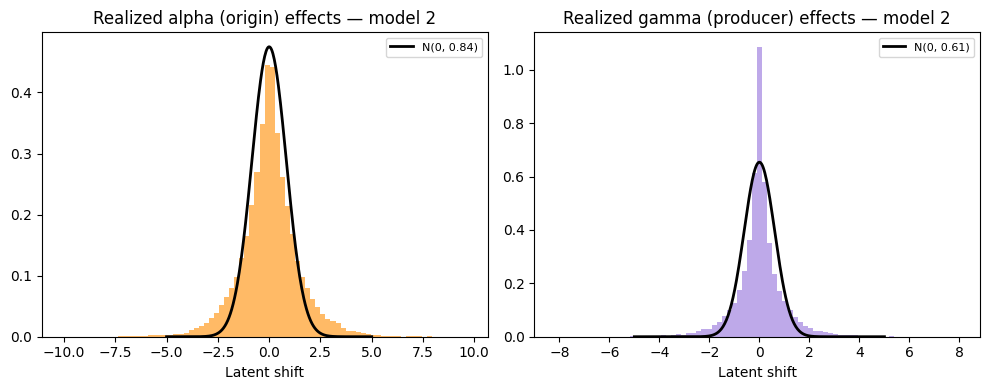

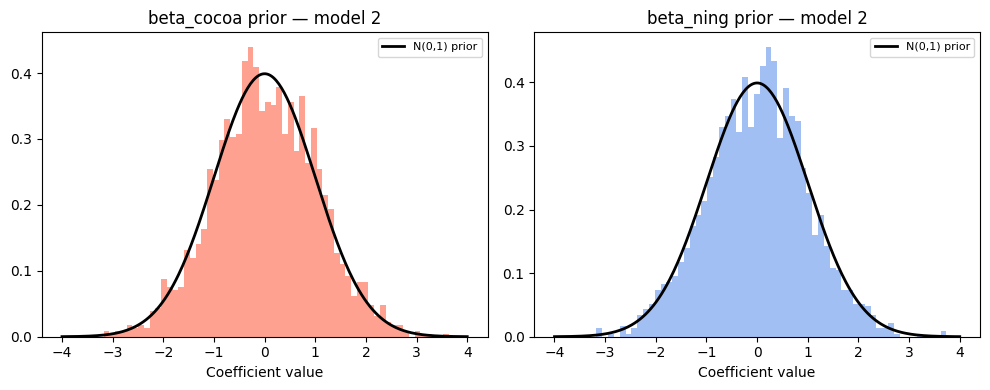

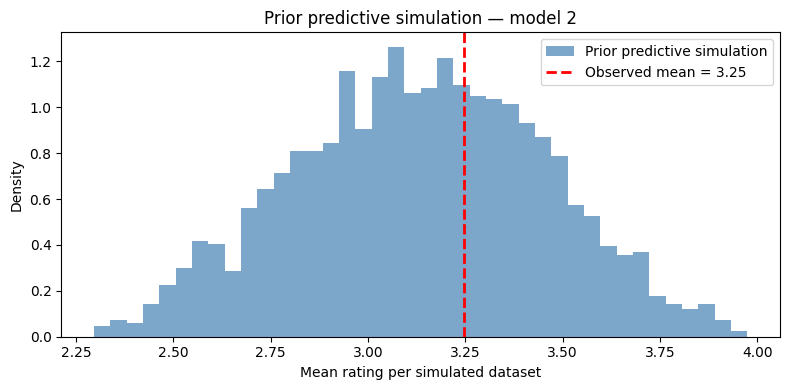

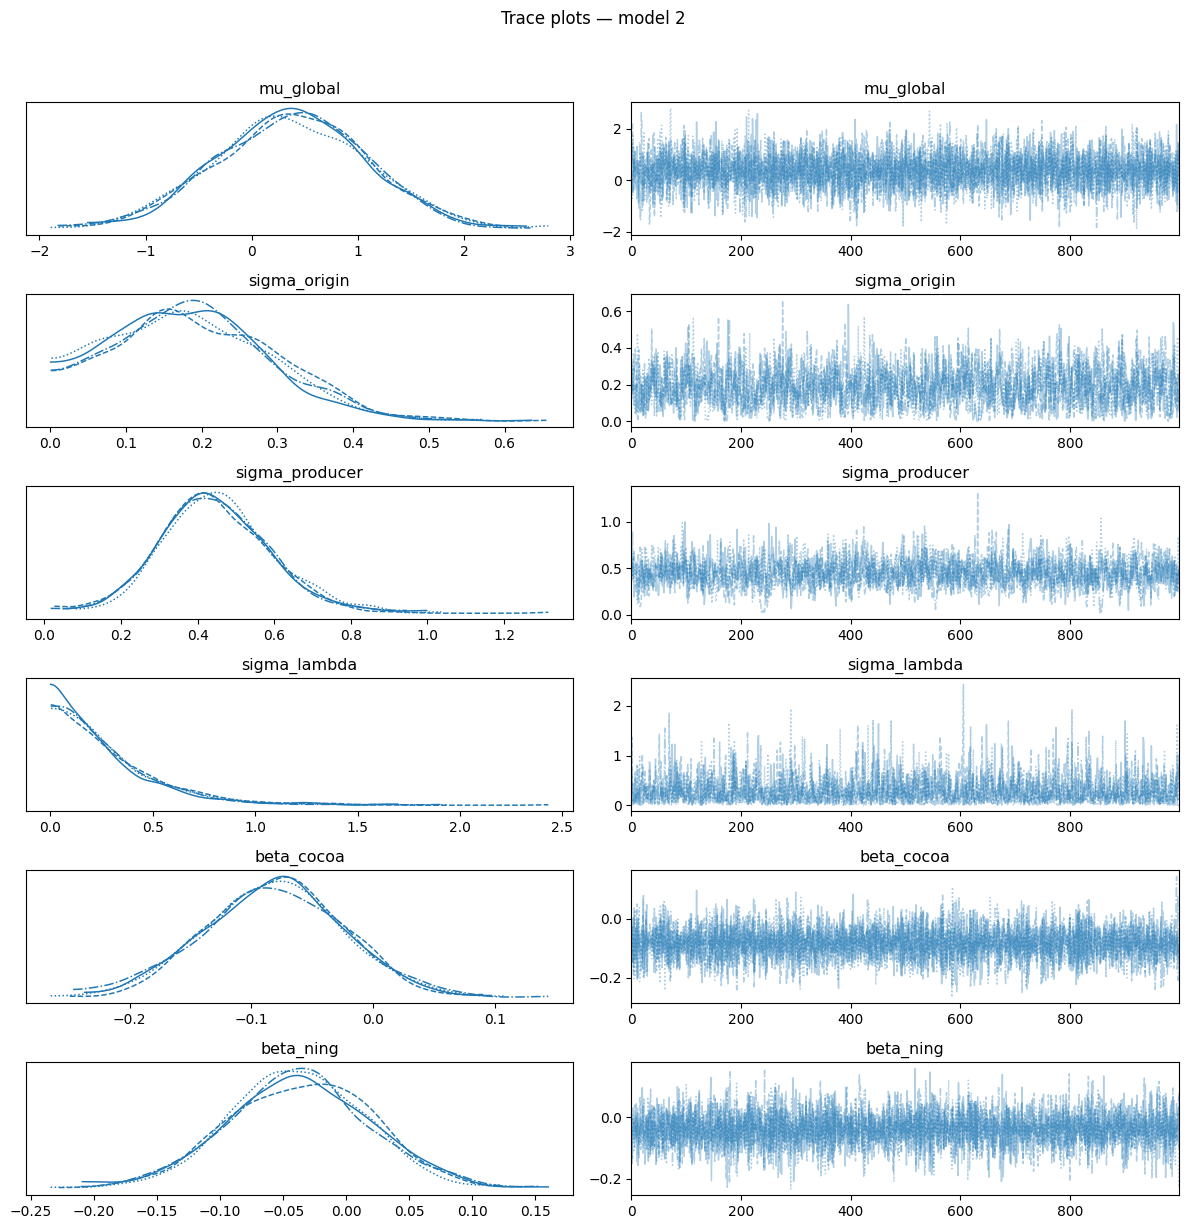

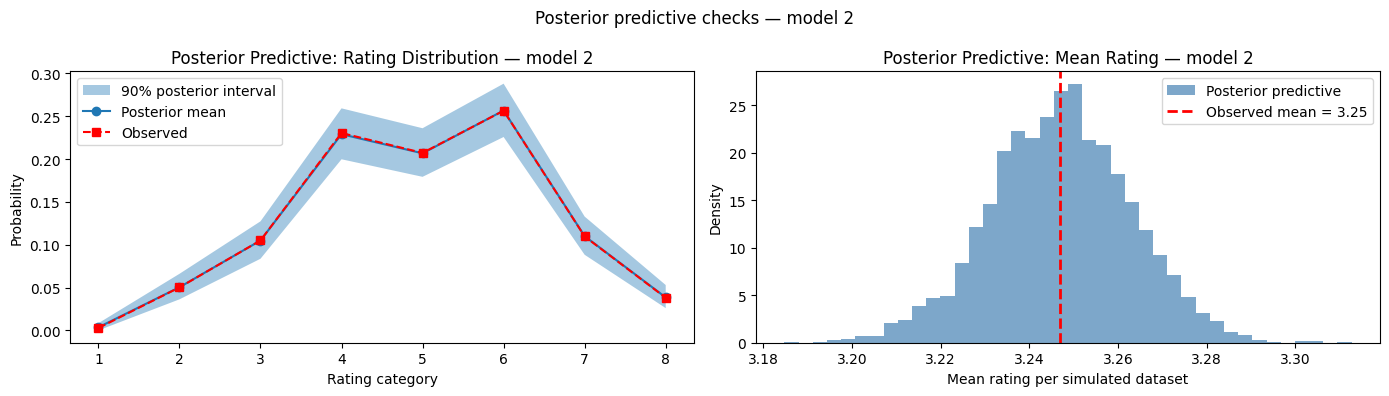

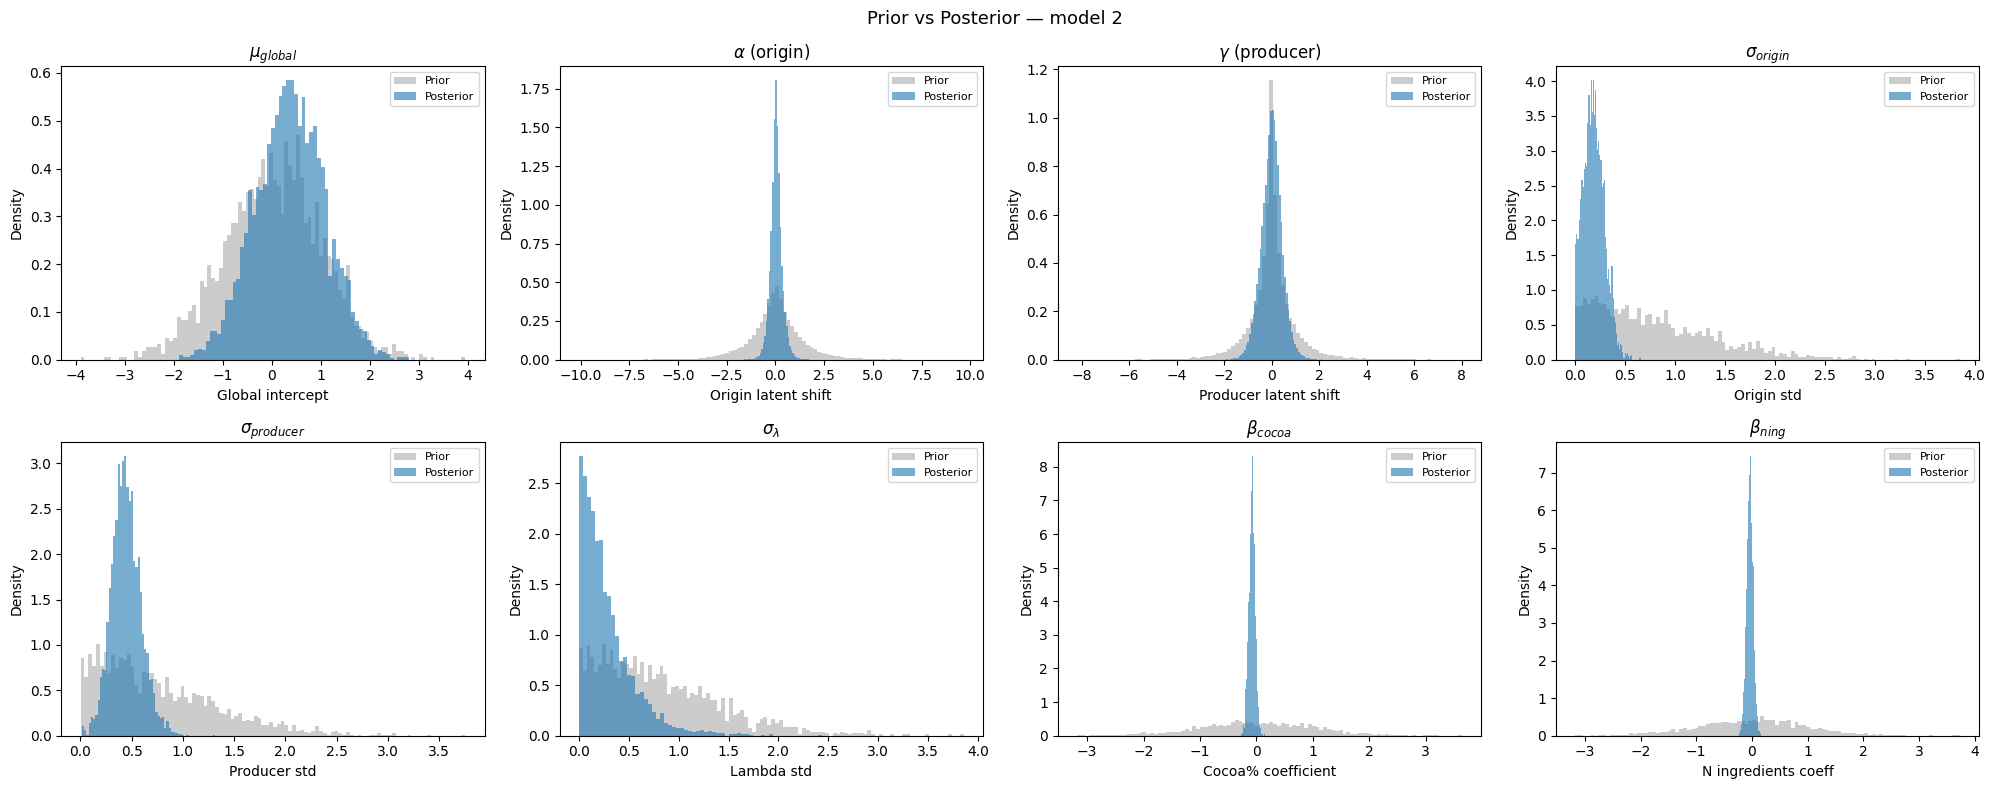

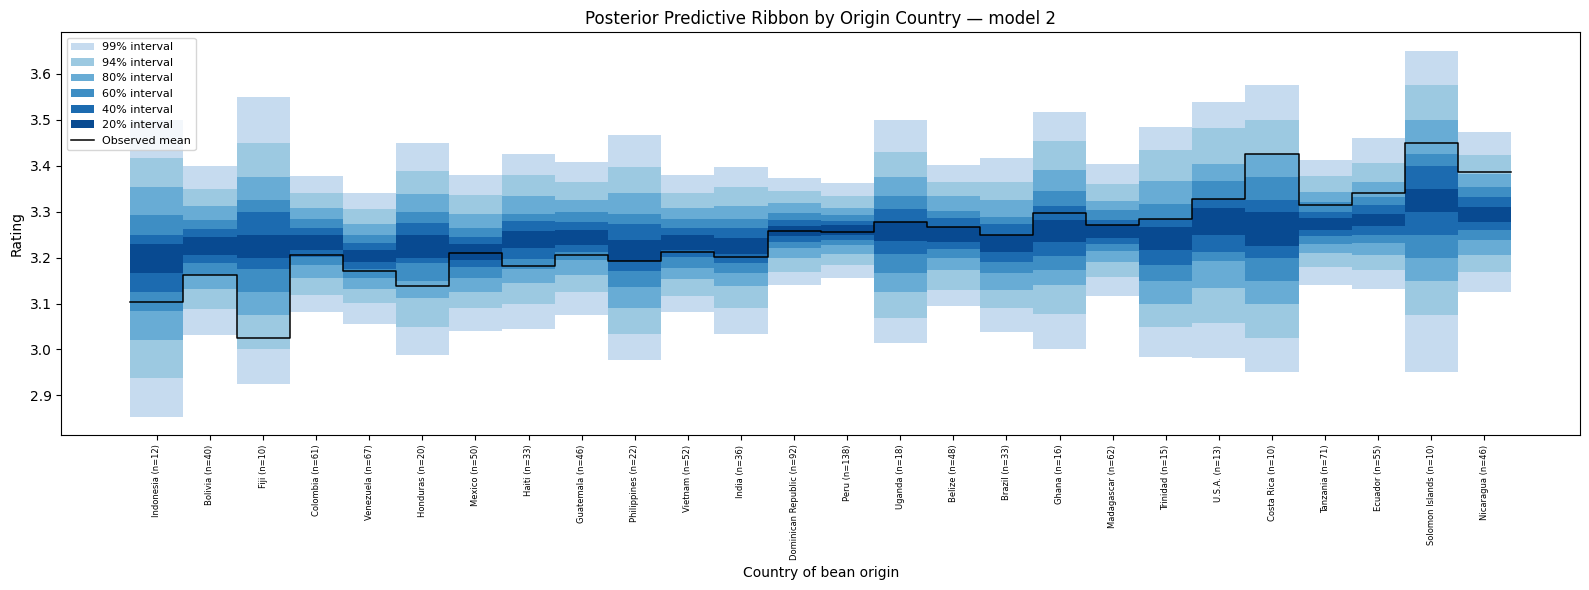

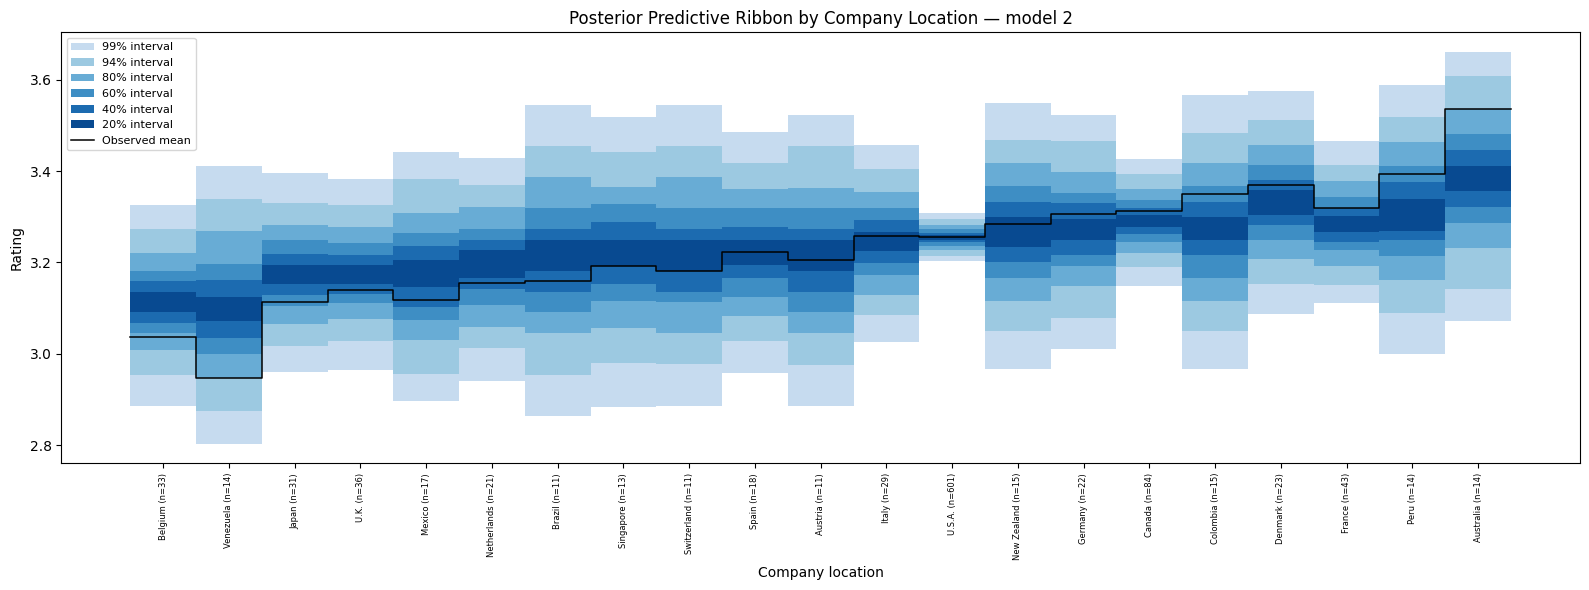

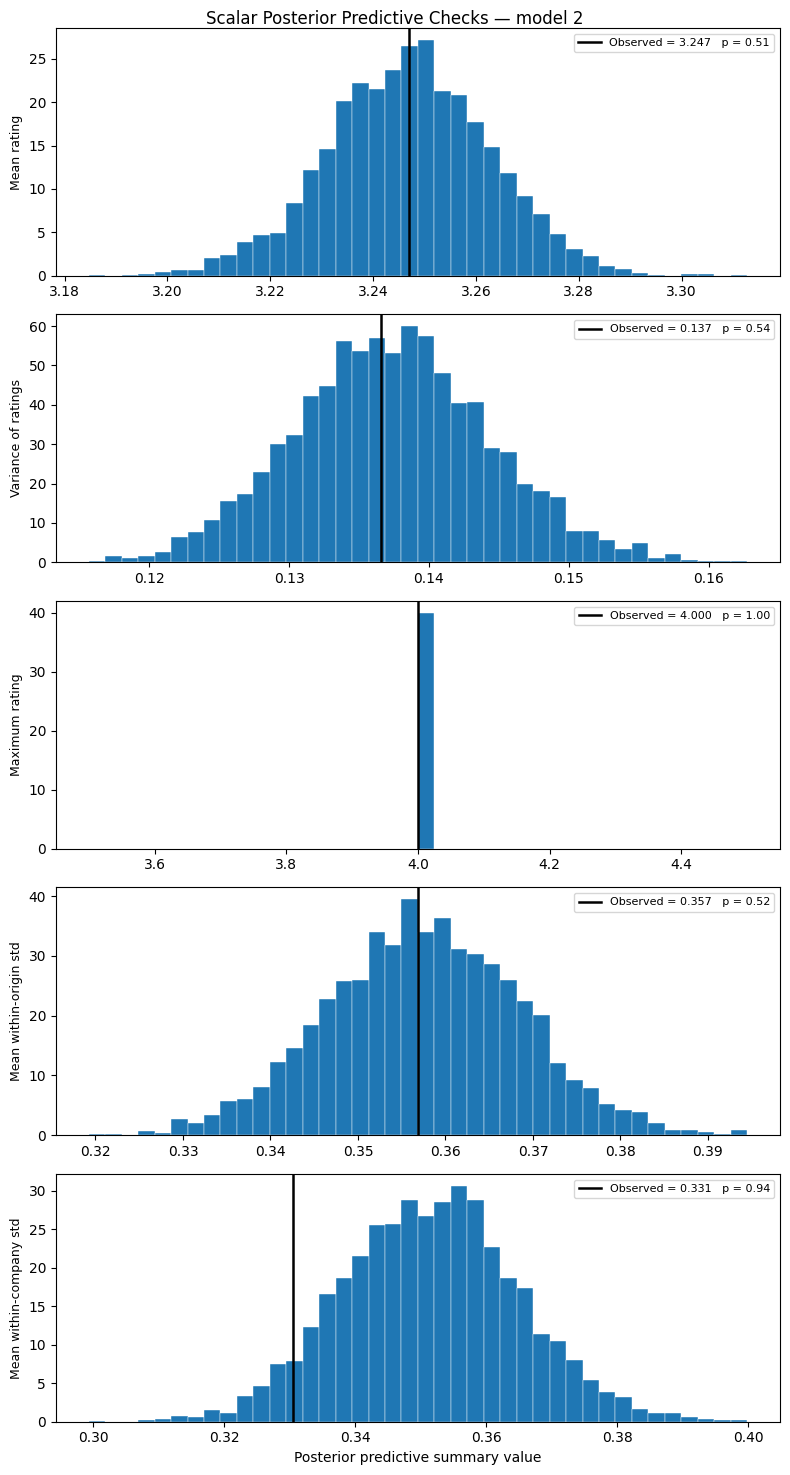

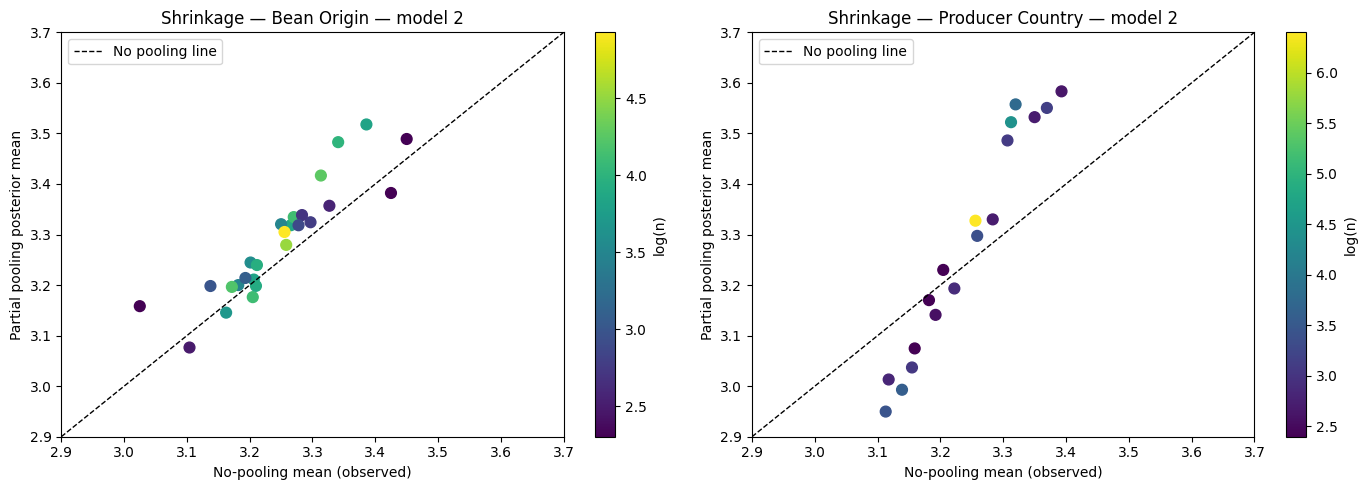

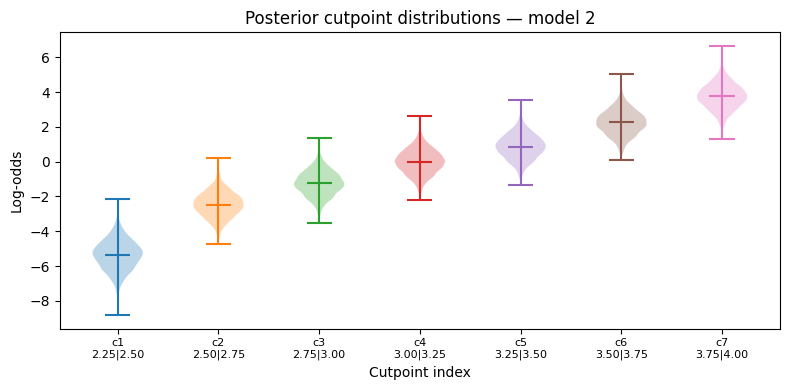

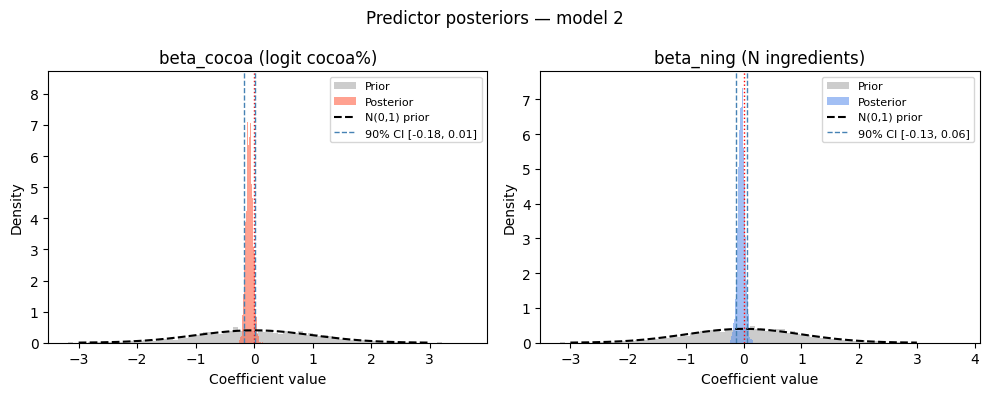

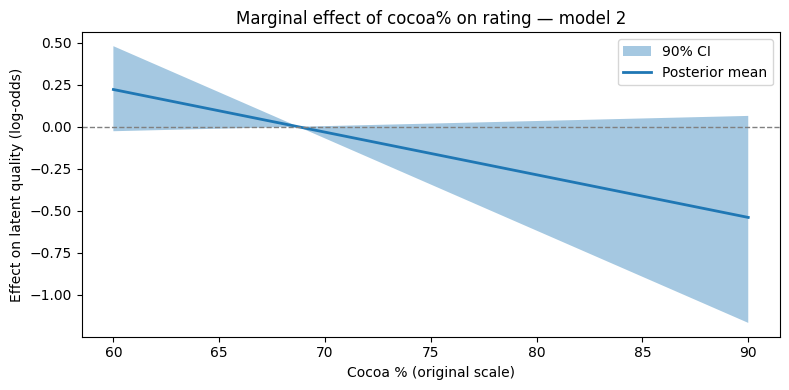

In [60]:
# ══════════════════════════════════════════════════════════════════════════════
# PRIOR PREDICTIVE CHECK — model 2
# ══════════════════════════════════════════════════════════════════════════════

alpha_prior2       = prior_fit2.stan_variable("alpha")
gamma_prior2       = prior_fit2.stan_variable("gamma")
sigma_origin_prior2  = prior_fit2.stan_variable("sigma_origin")
sigma_prod_prior2    = prior_fit2.stan_variable("sigma_producer")
sigma_lam_prior2     = prior_fit2.stan_variable("sigma_lambda")
mu_global_prior2     = prior_fit2.stan_variable("mu_global")
c_prior_draws2       = prior_fit2.stan_variable("c")

id_to_rating         = np.vectorize(inv_rating_map.get)
rating_pred_values2  = id_to_rating(rating_pred_prior2)

# ── 1. Rating distribution ────────────────────────────────────────────────────
pred_counts2 = np.apply_along_axis(
    lambda x: np.bincount(x.astype(int) - 1, minlength=C), 1, rating_pred_prior2
)
pred_probs2 = pred_counts2 / pred_counts2.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(
    range(1, C+1),
    np.percentile(pred_probs2, 5,  axis=0),
    np.percentile(pred_probs2, 95, axis=0),
    alpha=0.4, label="90% prior interval"
)
ax.plot(range(1, C+1), pred_probs2.mean(axis=0), marker='o', label="Prior mean")
ax.axhline(1/C, ls='--', color='gray', label=f"Uniform (1/{C})")
ax.set_xlabel("Rating category"); ax.set_ylabel("Probability")
ax.set_title("Prior Predictive: Rating Distribution — model 2")
ax.set_xticks(range(1, C+1))
ax.set_xticklabels([inv_rating_map[i+1] for i in range(C)])
ax.legend()
plt.tight_layout(); plt.show()

# ── 2. Cutpoint spacing ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for k in range(C - 1):
    ax.boxplot(c_prior_draws2[:, k], positions=[k+1], widths=0.6,
               medianprops=dict(color='black'))
ax.set_xlabel("Cutpoint index k"); ax.set_ylabel("Log-odds value")
ax.set_title("Prior Cutpoint Spacing — model 2")
ax.set_xticks(range(1, C+1))
ax.set_xticklabels([inv_rating_map[i+1] for i in range(C)])
plt.tight_layout(); plt.show()

# ── 3. Sigma marginals ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x = np.linspace(0, 4, 300)
ref = stats.halfnorm.pdf(x, scale=1.0)
for ax, samples, name, color in zip(
    axes,
    [sigma_origin_prior2, sigma_prod_prior2],
    ["sigma_origin", "sigma_producer"],
    ["steelblue", "seagreen"]
):
    ax.hist(samples, bins=50, density=True, alpha=0.6, color=color)
    ax.plot(x, ref, 'k-', lw=2, label="HalfNormal(1) PDF")
    ax.axvline(np.percentile(samples, 95), ls='--', color='gray',
               label=f"95th pct = {np.percentile(samples,95):.2f}")
    ax.set_title(f"{name} — model 2"); ax.set_xlabel("Value")
    ax.set_ylim([0, 4]); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# ── 4. Realized group effects ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, draws, name, color in zip(
    axes,
    [alpha_prior2, gamma_prior2],
    ["alpha (origin)", "gamma (producer)"],
    ["darkorange", "mediumpurple"]
):
    ax.hist(draws.flatten(), bins=80, density=True, alpha=0.6, color=color)
    med_sigma = np.median(draws.std(axis=1))
    x = np.linspace(-5, 5, 300)
    ax.plot(x, stats.norm.pdf(x, 0, med_sigma), 'k-', lw=2,
            label=f"N(0, {med_sigma:.2f})")
    ax.set_title(f"Realized {name} effects — model 2")
    ax.set_xlabel("Latent shift"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# ── 5. Beta marginals (new for model 2) ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x = np.linspace(-4, 4, 300)
for ax, samples, name, color in zip(
    axes,
    [beta_cocoa_prior, beta_ning_prior],
    ["beta_cocoa", "beta_ning"],
    ["tomato", "cornflowerblue"]
):
    ax.hist(samples, bins=60, density=True, alpha=0.6, color=color)
    ax.plot(x, stats.norm.pdf(x, 0, 1), 'k-', lw=2, label="N(0,1) prior")
    ax.set_title(f"{name} prior — model 2")
    ax.set_xlabel("Coefficient value"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# ── 6. Prior predictive mean ──────────────────────────────────────────────────
prior_draw_means2 = rating_pred_values2.mean(axis=1)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prior_draw_means2, bins=40, density=True, alpha=0.7,
        color="steelblue", label="Prior predictive simulation")
ax.axvline(df["Rating"].mean(), color="red", lw=2, ls="--",
           label=f"Observed mean = {df['Rating'].mean():.2f}")
ax.set_xlabel("Mean rating per simulated dataset"); ax.set_ylabel("Density")
ax.set_title("Prior predictive simulation — model 2")
ax.legend(); plt.tight_layout(); plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# MCMC DIAGNOSTICS — model 2
# ══════════════════════════════════════════════════════════════════════════════

az.plot_trace(idata2, var_names=["mu_global", "sigma_origin", "sigma_producer",
                                  "sigma_lambda", "beta_cocoa", "beta_ning"])
plt.suptitle("Trace plots — model 2", y=1.02)
plt.tight_layout(); plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# POSTERIOR PREDICTIVE CHECKS — model 2
# ══════════════════════════════════════════════════════════════════════════════

pred_counts2_post = np.apply_along_axis(
    lambda x: np.bincount(x.astype(int) - 1, minlength=C),
    1, rating_pred_post2
)
pred_probs2_post = pred_counts2_post / pred_counts2_post.sum(axis=1, keepdims=True)
obs_counts = np.bincount(df['rating_id'].values.astype(int) - 1, minlength=C)
obs_probs  = obs_counts / obs_counts.sum()

# ── 7. Rating distribution + mean ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
ax.fill_between(
    range(1, C+1),
    np.percentile(pred_probs2_post, 5,  axis=0),
    np.percentile(pred_probs2_post, 95, axis=0),
    alpha=0.4, label="90% posterior interval"
)
ax.plot(range(1, C+1), pred_probs2_post.mean(axis=0), marker='o', label="Posterior mean")
ax.plot(range(1, C+1), obs_probs, marker='s', color='red', ls='--', label="Observed")
ax.set_xlabel("Rating category"); ax.set_ylabel("Probability")
ax.set_title("Posterior Predictive: Rating Distribution — model 2")
ax.legend()

ax = axes[1]
ax.hist(rating_pred_vals2.mean(axis=1), bins=40, density=True, alpha=0.7,
        color="steelblue", label="Posterior predictive")
ax.axvline(df["Rating"].mean(), color="red", lw=2, ls="--",
           label=f"Observed mean = {df['Rating'].mean():.2f}")
ax.set_xlabel("Mean rating per simulated dataset"); ax.set_ylabel("Density")
ax.set_title("Posterior Predictive: Mean Rating — model 2")
ax.legend()
plt.suptitle("Posterior predictive checks — model 2")
plt.tight_layout(); plt.show()

# ── 8. Prior vs posterior ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

panels2 = [
    (mu_global_samples2,       mu_global_prior2,        r"$\mu_{global}$",      "Global intercept"),
    (alpha_samples2.flatten(), alpha_prior2.flatten(),   r"$\alpha$ (origin)",   "Origin latent shift"),
    (gamma_samples2.flatten(), gamma_prior2.flatten(),   r"$\gamma$ (producer)", "Producer latent shift"),
    (sigma_origin2,            sigma_origin_prior2,      r"$\sigma_{origin}$",   "Origin std"),
    (sigma_producer2,          sigma_prod_prior2,        r"$\sigma_{producer}$", "Producer std"),
    (sigma_lambda2,            sigma_lam_prior2,         r"$\sigma_{\lambda}$",  "Lambda std"),
    (beta_cocoa_post,          beta_cocoa_prior,         r"$\beta_{cocoa}$",     "Cocoa% coefficient"),
    (beta_ning_post,           beta_ning_prior,          r"$\beta_{ning}$",      "N ingredients coeff"),
]

for ax, (post, prior, title, xlabel) in zip(axes, panels2):
    ax.hist(prior, bins=100, density=True, alpha=0.4, color="gray", label="Prior")
    ax.hist(post,  bins=60,  density=True, alpha=0.6, label="Posterior")
    ax.set_title(title); ax.set_xlabel(xlabel)
    ax.set_ylabel("Density"); ax.legend(fontsize=8)

plt.suptitle("Prior vs Posterior — model 2", fontsize=13)
plt.tight_layout(); plt.show()

# ── 9. Ribbon by origin country ───────────────────────────────────────────────
mu_origin_total2 = mu_global_samples2[:, None] + alpha_samples2
num_draws2 = rating_pred_vals2.shape[0]

results21 = pd.DataFrame({
    "country":     countries,
    "mu_mean":     mu_origin_total2.mean(axis=0),
    "n_bars":      [counts_origin.get(c, 0) for c in countries],
}).sort_values("mu_mean", ascending=True).reset_index(drop=True)

obs_sorted_origin2 = results21["country"].map(
    lambda c: observed_per_country1[country_idx[c]]
).values

J_sorted2 = len(results21)
x2b = np.arange(1, J_sorted2 + 1)

post_pred_means_origin2 = np.zeros((num_draws2, J_sorted2))
for i, country_name in enumerate(results21["country"]):
    idx = current_df[current_df["Country of Bean Origin"] == country_name].index.values
    post_pred_means_origin2[:, i] = rating_pred_vals2[:, idx].mean(axis=1)

fig, ax = plt.subplots(figsize=(16, 6))
for lev, color in zip(levels, colors):
    lo = np.percentile(post_pred_means_origin2, (100-lev)/2,       axis=0)
    hi = np.percentile(post_pred_means_origin2, 100-(100-lev)/2,   axis=0)
    e, ls = step_edges(lo, x2b); _, hs = step_edges(hi, x2b)
    ax.fill_between(e, ls, hs, step="pre", color=color, linewidth=0,
                    label=f"{lev}% interval")
e, os2 = step_edges(obs_sorted_origin2, x2b)
ax.step(e, os2, where="pre", color="black", linewidth=1.1, label="Observed mean")
ax.set_xticks(x2b)
ax.set_xticklabels(
    [f"{r['country']} (n={r['n_bars']})" for _, r in results21.iterrows()],
    rotation=90, fontsize=6
)
ax.set_xlabel("Country of bean origin"); ax.set_ylabel("Rating")
ax.set_title("Posterior Predictive Ribbon by Origin Country — model 2")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

# ── 10. Ribbon by producer country ───────────────────────────────────────────
mu_company_total2 = mu_global_samples2[:, None] + gamma_samples2

results22 = pd.DataFrame({
    "company":  company_locations,
    "mu_mean":  mu_company_total2.mean(axis=0),
    "n_bars":   [counts_company.get(c, 0) for c in company_locations],
}).sort_values("mu_mean", ascending=True).reset_index(drop=True)

obs_sorted_company2 = results22["company"].map(
    lambda c: observed_per_company1[company_idx[c]]
).values

K_sorted2 = len(results22)
x3b = np.arange(1, K_sorted2 + 1)

post_pred_means_company2 = np.zeros((num_draws2, K_sorted2))
for i, comp_name in enumerate(results22["company"]):
    idx = current_df[current_df["Company Location"] == comp_name].index.values
    post_pred_means_company2[:, i] = rating_pred_vals2[:, idx].mean(axis=1)

fig, ax = plt.subplots(figsize=(16, 6))
for lev, color in zip(levels, colors):
    lo = np.percentile(post_pred_means_company2, (100-lev)/2,     axis=0)
    hi = np.percentile(post_pred_means_company2, 100-(100-lev)/2, axis=0)
    e, ls = step_edges(lo, x3b); _, hs = step_edges(hi, x3b)
    ax.fill_between(e, ls, hs, step="pre", color=color, linewidth=0,
                    label=f"{lev}% interval")
e, cs2 = step_edges(obs_sorted_company2, x3b)
ax.step(e, cs2, where="pre", color="black", linewidth=1.1, label="Observed mean")
ax.set_xticks(x3b)
ax.set_xticklabels(
    [f"{r['company']} (n={r['n_bars']})" for _, r in results22.iterrows()],
    rotation=90, fontsize=6
)
ax.set_xlabel("Company location"); ax.set_ylabel("Rating")
ax.set_title("Posterior Predictive Ribbon by Company Location — model 2")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

# ── 11. Scalar PPCs ───────────────────────────────────────────────────────────
obs = df["Rating"].values

rep_mean2 = rating_pred_vals2.mean(axis=1)
rep_var2  = rating_pred_vals2.var(axis=1)
rep_max2  = rating_pred_vals2.max(axis=1)

country_sds_rep2 = np.zeros((num_draws2, J_sorted2))
country_sds_obs2 = np.zeros(J_sorted2)
for i, country_name in enumerate(results21["country"]):
    idx = current_df[current_df["Country of Bean Origin"] == country_name].index.values
    if len(idx) > 1:
        country_sds_rep2[:, i] = rating_pred_vals2[:, idx].std(axis=1)
        country_sds_obs2[i]    = obs[idx].std()

company_sds_rep2 = np.zeros((num_draws2, K_sorted2))
company_sds_obs2 = np.zeros(K_sorted2)
for i, comp_name in enumerate(results22["company"]):
    idx = current_df[current_df["Company Location"] == comp_name].index.values
    if len(idx) > 1:
        company_sds_rep2[:, i] = rating_pred_vals2[:, idx].std(axis=1)
        company_sds_obs2[i]    = obs[idx].std()

checks2 = [
    (rep_mean2,                         obs.mean(),                     "Mean rating"),
    (rep_var2,                          obs.var(),                      "Variance of ratings"),
    (rep_max2,                          obs.max(),                      "Maximum rating"),
    (country_sds_rep2.mean(axis=1),     country_sds_obs2.mean(),        "Mean within-origin std"),
    (company_sds_rep2.mean(axis=1),     company_sds_obs2.mean(),        "Mean within-company std"),
]

fig, axes = plt.subplots(5, 1, figsize=(8, 15))
for ax, (rep_stat, obs_stat, ylabel) in zip(axes, checks2):
    ax.hist(rep_stat, bins=40, density=True, edgecolor="white", linewidth=0.3)
    p_val = np.mean(rep_stat >= obs_stat)
    ax.axvline(obs_stat, color="k", linewidth=1.8,
               label=f"Observed = {obs_stat:.3f}   p = {p_val:.2f}")
    ax.set_ylabel(ylabel, fontsize=9); ax.legend(fontsize=8)
axes[-1].set_xlabel("Posterior predictive summary value", fontsize=10)
plt.suptitle("Scalar Posterior Predictive Checks — model 2", fontsize=12)
plt.tight_layout(); plt.show()

# ── 12. Shrinkage ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
grand_mean = df['Rating'].mean()

for ax, samples, id_col, title in zip(
    axes,
    [alpha_samples2, gamma_samples2],
    ['Bean Origin ID', 'Company Location ID'],
    ['Bean Origin', 'Producer Country']
):
    group_obs_mean = df.groupby(id_col)['Rating'].mean()
    group_ns       = df.groupby(id_col)['Rating'].count()
    post_rating_mean = grand_mean + samples.mean(axis=0)

    sc = ax.scatter(group_obs_mean.values, post_rating_mean,
                    c=np.log(group_ns.values), cmap='viridis', s=60)
    plt.colorbar(sc, ax=ax, label='log(n)')
    lims = [2.9, 3.7]
    ax.plot(lims, lims, 'k--', lw=1, label='No pooling line')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('No-pooling mean (observed)')
    ax.set_ylabel('Partial pooling posterior mean')
    ax.set_title(f'Shrinkage — {title} — model 2')
    ax.legend()
plt.tight_layout(); plt.show()

# ── 13. Cutpoint posteriors ───────────────────────────────────────────────────
rating_labels = ['2.25|2.50', '2.50|2.75', '2.75|3.00',
                 '3.00|3.25', '3.25|3.50', '3.50|3.75', '3.75|4.00']
fig, ax = plt.subplots(figsize=(8, 4))
for k in range(C - 1):
    ax.violinplot(c_samples2[:, k], positions=[k+1], showmedians=True)
ax.set_xlabel('Cutpoint index'); ax.set_ylabel('Log-odds')
ax.set_title('Posterior cutpoint distributions — model 2')
ax.set_xticks(range(1, 8))
ax.set_xticklabels([f'c{k}\n{rating_labels[k-1]}' for k in range(1, 8)], fontsize=8)
plt.tight_layout(); plt.show()

# ── 14. Beta posteriors — model 2 specific ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x = np.linspace(-3, 3, 300)
for ax, post, prior, name, color in zip(
    axes,
    [beta_cocoa_post, beta_ning_post],
    [beta_cocoa_prior, beta_ning_prior],
    ["beta_cocoa (logit cocoa%)", "beta_ning (N ingredients)"],
    ["tomato", "cornflowerblue"]
):
    ax.hist(prior, bins=80, density=True, alpha=0.4, color='gray', label='Prior')
    ax.hist(post,  bins=60, density=True, alpha=0.6, color=color,  label='Posterior')
    ax.plot(x, stats.norm.pdf(x, 0, 1), 'k--', lw=1.5, label='N(0,1) prior')
    ax.axvline(0, color='red', ls=':', lw=1)
    ax.axvline(np.percentile(post, 5),  color='steelblue', ls='--', lw=1)
    ax.axvline(np.percentile(post, 95), color='steelblue', ls='--', lw=1,
               label=f"90% CI [{np.percentile(post,5):.2f}, {np.percentile(post,95):.2f}]")
    ax.set_title(name); ax.set_xlabel("Coefficient value")
    ax.set_ylabel("Density"); ax.legend(fontsize=8)
plt.suptitle("Predictor posteriors — model 2")
plt.tight_layout(); plt.show()

# ── 15. Cocoa% marginal effect ────────────────────────────────────────────────
cocoa_grid   = np.linspace(df['cocoa_logit_norm'].min(),
                            df['cocoa_logit_norm'].max(), 100)
cocoa_effect = np.outer(beta_cocoa_post, cocoa_grid)

# x-axis in original cocoa% for readability
cocoa_orig = np.linspace(cocoa_num.min(), cocoa_num.max(), 100)

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(
    cocoa_orig * 100,
    np.percentile(cocoa_effect, 5,  axis=0),
    np.percentile(cocoa_effect, 95, axis=0),
    alpha=0.4, label="90% CI"
)
ax.plot(cocoa_orig * 100, cocoa_effect.mean(axis=0), lw=2, label="Posterior mean")
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_xlabel("Cocoa % (original scale)")
ax.set_ylabel("Effect on latent quality (log-odds)")
ax.set_title("Marginal effect of cocoa% on rating — model 2")
ax.legend(); plt.tight_layout(); plt.show()


## Model comapirson

Both models were compared using two information criteria: WAIC 
(Widely Applicable Information Criterion) and PSIS-LOO 
(Pareto-Smoothed Importance Sampling Leave-One-Out Cross-Validation), 
computed via ArviZ from the log-likelihood values stored in the 
generated quantities block of each model.

         rank    elpd_waic     p_waic  elpd_diff    weight         se  \
Model 1     0 -1918.143101  26.208045   0.000000  0.888973  18.957899   
Model 2     1 -1919.095018  28.714976   0.951918  0.111027  18.980556   

              dse  warning scale  
Model 1  0.000000    False   log  
Model 2  1.560468    False   log  


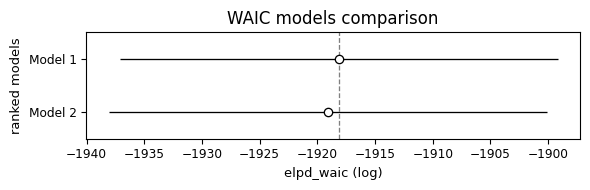

         rank     elpd_loo      p_loo  elpd_diff    weight         se  \
Model 1     0 -1918.216084  26.281029   0.000000  0.890062  18.960904   
Model 2     1 -1919.170687  28.790644   0.954602  0.109938  18.983398   

              dse  warning scale  
Model 1  0.000000    False   log  
Model 2  1.560438    False   log  


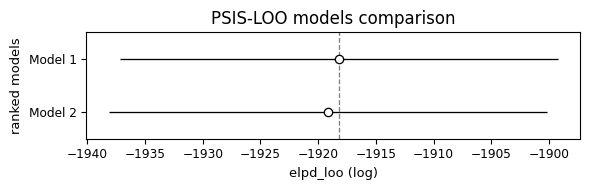

In [61]:
comp_dict = {
    "Model 1": fit1,
    "Model 2": fit2
}
comp_waic = az.compare(comp_dict, ic="waic")
print(comp_waic)

az.plot_compare(comp_waic)
plt.title("WAIC models comparison")
plt.tight_layout()
plt.show()

comp_loo = az.compare(comp_dict, ic="loo")
print(comp_loo)

az.plot_compare(comp_loo)
plt.title("PSIS-LOO models comparison")
plt.tight_layout()
plt.show()

### WAIC

Model 2  achieves higher expected log predictive density under WAIC (elpd_waic = -431.9) than Model 1 (elpd_waic = -447.9), with a difference of 16. No warnings were issued for either model. The standard error of the difference (dse = 6.62) yields a ratio of elpd_diff/dse ≈ 2.42, indicating that the difference is statistically meaningful and not attributable to sampling noise. While the confidence intervals in the comparison plot visually overlap, this reflects uncertainty in each model's absolute elpd estimate rather than the uncertainty in their difference, the latter is captured by dse and supports an advantage for Model 2.

### PSIS - LOO

The PSIS-LOO results are consistent with WAIC. Model 2 achieves elpd_loo = -432.0 versus Model 1's - 448.0, a difference of 15.98 with dse = 6.62. No Pareto k warnings were issued, indicating that the importance sampling approximation is reliable for all observations in both models and that neither model is driven by a small number of highly influential points.
The ratio elpd_diff/dse ≈ 2.41 again exceeds 2, confirming Model 2 as the preferred model under PSIS-LOO. The near-identical results across both criteria (WAIC and LOO differ by less than 0.1 points) indicate that no outlier observations are distorting the comparison.

### Summary

Both criteria select Model 2 as the better predictive model and the difference is statistically meaningful (elpd_diff/dse $\approx$ 2.4 > 2). Model 2 additional predictors, such as number of ingredients, presence of vanilla, cocoa percantage and review year, provide genuine predictive signal beyond country level effects. This improvement is expected, as 
models with more parameters generally capture more variation in the data.

Model 2 is preffered model when complete chocolate ingredient information is available. However Model 1 also performs well and in our opinion, the practical difference between them is minor. Model 1 remains good alternative, particularly when only geographical information about bean origin and manufacturer is known, as it achieves comparable predictive performance with lower complexity.

## Sources
[1] : [Statista. (2026). Chocolate Confectionery - Worldwide: Market Insights & Forecast. Statista Consumer Market Outlook](https://www.statista.com/outlook/cmo/food/confectionery-snacks/confectionery/chocolate-confectionery/worldwide/?srsltid=AfmBOorxi7XFaZWdLCVjMUYGtJAp6RNSvUAMPQz5kLmDYZJz0M03wTzj)

[2] : [HTF Market Intelligence. (2026). Global Fine or Flavor Cocoa Market: Size, Industry Analysis, Trends, and Forecast to 2033. HTF Market Report.](https://www.htfmarketintelligence.com/report/global-fine-or-flavor-cocoa-market)

[3] : [Grand View Research. (2026). Chocolate Market Size, Share & Trends Analysis Report by Product (Traditional, Artificial), by Distribution Channel, and Segment Forecasts 2026 - 2033. Grand View Research.](https://www.grandviewresearch.com/industry-analysis/chocolate-market)

[4] : [Fanning, E., Eyres, G., Frew, R., & Kebede, B. (2023). Linking cocoa quality attributes to its origin using geographical indications. Food Control, 151, 109825.](https://www.sciencedirect.com/science/article/pii/S0956713523002256)